In [2]:
!pip uninstall -y dopamine-rl

In [3]:
!pip install ale-py --upgrade
!pip install gymnasium==0.28.1
!pip install 'stable-baselines3[extra]'
!pip install yfinance pandas
!pip install ta
!pip install PyPortfolioOpt
!pip install wandb
!pip install 'shimmy>=2.0'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 25.2 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 9.7 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 944.3/944.3 kB 18.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 56.4 MB/s eta 0:00:0000:010:01
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 0.28.1
    Uninstalling gymnasium-0.28.1:
      Successfully uninstalled gymnasium-0.28.1

[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 

In [4]:
!pip install git+https://github.com/DLR-RM/stable-baselines3

  Cloning https://github.com/DLR-RM/stable-baselines3 to /tmp/pip-req-build-71l4_48m
  Running command git clone --filter=blob:none --quiet https://github.com/DLR-RM/stable-baselines3 /tmp/pip-req-build-71l4_48m
  Resolved https://github.com/DLR-RM/stable-baselines3 to commit dd7f5bfe63631630463f2f9bcb4762e6c040de12
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for stable_baselines3: filename=stable_baselines3-2.7.1a0-py3-none-any.whl size=187348 sha256=b198b0e215b87513e2933205991d7fbb04a0b52bc19f38564a6726254d254b29
  Stored in directory: /tmp/pip-ephem-wheel-cache-wmasnuog/wheels/3b/24/65/bc2794face336930a72bdbe36faf5aad6e2352b3d1dec310ca
Successfully built stable_baselines3
  Attempting uninstall: stable_baselines3
    Found existing installation: stable_baselines3 2.7.0
    Uninstalling stable_baselines3-2.7.0:
      Successfully uninstalled stable_baselines3-2.7.0

[notice] A n

In [5]:
pip install git+https://github.com/Stable-Baselines-Team/stable-baselines3-contrib

  Cloning https://github.com/Stable-Baselines-Team/stable-baselines3-contrib to /tmp/pip-req-build-_oz3pvds
  Running command git clone --filter=blob:none --quiet https://github.com/Stable-Baselines-Team/stable-baselines3-contrib /tmp/pip-req-build-_oz3pvds
  Resolved https://github.com/Stable-Baselines-Team/stable-baselines3-contrib to commit 33889dbb215b8992bf463551657b79241f4bccf8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for sb3_contrib: filename=sb3_contrib-2.7.0-py3-none-any.whl size=93173 sha256=aa35cdaa5cb51019168aa7434d49b6363d30495e9b3a4e125d2a5c56232ab5ae
  Stored in directory: /tmp/pip-ephem-wheel-cache-2j4fints/wheels/f8/e1/97/7e886248901c65ffe4ff7a9c16bccfbde992692ac10d99ee41
Successfully built sb3_contrib

[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use up

In [10]:
import shutil
import os

folders = ["results", "models", "wandb_logs"]

for p in folders:
    folder_path = "/kaggle/working/" + p

    # Check if folder exists, then remove it
    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
        print(f"Folder '{folder_path}' deleted.")

Folder '/kaggle/working/results' deleted.


In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta
from ta import add_all_ta_features
from ta.trend import SMAIndicator, EMAIndicator, MACD, CCIIndicator, ADXIndicator
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator
from ta.utils import dropna
import itertools
import pandas as pd
import numpy as np

In [12]:
from __future__ import annotations

from typing import List

import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gymnasium import spaces
from gymnasium.utils import seeding
from stable_baselines3.common.vec_env import DummyVecEnv

matplotlib.use("Agg")
%matplotlib inline

# from stable_baselines3.common.logger import Logger, KVWriter, CSVOutputFormat

E0000 00:00:1755701103.259742      10 common_lib.cc:612] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:230


In [17]:
# DRL models from Stable Baselines 3
import statistics
import time

import numpy as np
import pandas as pd
from stable_baselines3 import A2C
from stable_baselines3 import DDPG
from stable_baselines3 import PPO
from stable_baselines3 import SAC
from stable_baselines3 import TD3
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.callbacks import CallbackList
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.logger import configure

In [18]:
from pypfopt import expected_returns, risk_models
from pypfopt import EfficientFrontier
from scipy.stats import skew, kurtosis

In [19]:
import random
import wandb
from wandb.integration.sb3 import WandbCallback

In [20]:
!wandb login --relogin 320a98c6a9ba9e09b5d88d9b64059d763ae265f4

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [21]:
!pip install gdown


[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [22]:
import gdown

AAPL_FILE = "1OWBb2bIDJAclWwX66f3cFy-Oz6CDLscS"
gdown.download(f"https://drive.google.com/uc?id={AAPL_FILE}", "AAPL_f.json")

BA_FILE = "1QE3rVmHRZVO3jQcUQiEpm-3ykgFZHMIl"
gdown.download(f"https://drive.google.com/uc?id={BA_FILE}", "BA_f.json")

GS_FILE = "1m3VWETXQqxjgQawXb62jgzKAlNjQjUC-"
gdown.download(f"https://drive.google.com/uc?id={GS_FILE}", "GS_f.json")

JPM_FILE = "1eyTBEpg1dT3nB6EbRgKuYQmX0g7PBDLV"
gdown.download(f"https://drive.google.com/uc?id={JPM_FILE}", "JPM_f.json")

Downloading...
From: https://drive.google.com/uc?id=1OWBb2bIDJAclWwX66f3cFy-Oz6CDLscS
To: /kaggle/working/AAPL_f.json
100%|██████████| 6.86M/6.86M [00:00<00:00, 84.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QE3rVmHRZVO3jQcUQiEpm-3ykgFZHMIl
To: /kaggle/working/BA_f.json
100%|██████████| 6.91M/6.91M [00:00<00:00, 97.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1m3VWETXQqxjgQawXb62jgzKAlNjQjUC-
To: /kaggle/working/GS_f.json
100%|██████████| 6.91M/6.91M [00:00<00:00, 126MB/s]
Downloading...
From: https://drive.google.com/uc?id=1eyTBEpg1dT3nB6EbRgKuYQmX0g7PBDLV
To: /kaggle/working/JPM_f.json
100%|██████████| 5.31M/5.31M [00:00<00:00, 148MB/s]


'JPM_f.json'

In [23]:
DOW_30_TICKER = [
    #"AXP",
    #"AMGN",
    "AAPL",
    "BA",
    #"CAT",
    #"CSCO",
    #"CVX",
    "GS",
    #"HD",
    #"HON",
    #"IBM",
    #"INTC",
    #"JNJ",
    #"KO",
    "JPM",
    #"MCD",
    #"MMM",
    #"MRK",
    #"MSFT",
    #"NKE",
    #"PG",
    #"TRV",
    #"UNH",
    #"CRM",
    #"VZ",
    #"V",
    #"WBA",
    #"WMT",
    #"DIS",
    #"DOW",
]


INDICATORS_DOW_30 = [
    "ema_20", "ema_60",
    "macd", "macd_signal",
    "rsi_14", "cci_14",
    "atr_14", "boll_width",
    "boll_lb",
    "obv", "vol_sma_20",
    "vix", "vix_rolling_30",
    "ret_1d", "ret_5d", "mom_20d", "zclose_60",
    "rank_mom20", "rank_rsi_mom", "rank_rsi_mr",
    "finbert_future", "fingpt_future",
]

INDICATORS_DOW_30 = [
    "rank_mom20", "mom_20d",
    "rank_rsi_mr", "rsi_14", "rank_rsi_mom",
    "boll_width",
    "finbert_future", "fingpt_future",
    "zclose_60",       # optional
    "ret_1d",          # optional
]

"""
INDICATORS_DOW_30 = [
    "mom_20d",        # momentum trend
    "rsi_14",         # overbought/oversold
    "boll_width",     # volatility
    "finbert_future", # sentiment (text-based)
    "ret_1d",         # short-term price return
]
"""

'\nINDICATORS_DOW_30 = [\n    "mom_20d",        # momentum trend\n    "rsi_14",         # overbought/oversold\n    "boll_width",     # volatility\n    "finbert_future", # sentiment (text-based)\n    "ret_1d",         # short-term price return\n]\n'

In [24]:
CRYPTO_TICKER = [

]

In [25]:
def _adjust_prices(data_df: pd.DataFrame) -> pd.DataFrame:
    # use adjusted close price instead of close price
    data_df["adj"] = data_df["adjcp"] / data_df["close"]
    for col in ["open", "high", "low", "close"]:
        data_df[col] *= data_df["adj"]

    # drop the adjusted close price column
    return data_df.drop(["adjcp", "adj"], axis=1)

In [26]:
def get_data(dataset, start_date, end_date):
    if dataset == "DOW_30":
        """Fetches data from Yahoo API
        Returns
        -------
        `pd.DataFrame`
            7 columns: A date, open, high, low, close, volume and tick symbol
            for the specified stock ticker
        """
        # Download and save the data in a pandas DataFrame:
        data_df = pd.DataFrame()
        num_failures = 0
        for tic in DOW_30_TICKER:
            temp_df = yf.download(
                tic,
                start=start_date,
                end=end_date,
                auto_adjust=False,
            )
            if temp_df.columns.nlevels != 1:
                temp_df.columns = temp_df.columns.droplevel(1)
            temp_df["tic"] = tic
            if len(temp_df) > 0:
                data_df = pd.concat([data_df, temp_df], axis=0)
            else:
                num_failures += 1

        if num_failures == len(DOW_30_TICKER):
            raise ValueError("no data is fetched.")

        # reset the index, we want to use numbers as index instead of dates
        data_df = data_df.reset_index()
        try:
            # convert the column names to standardized names
            data_df.rename(
                columns={
                    "Date": "date",
                    "Adj Close": "adjcp",
                    "Close": "close",
                    "High": "high",
                    "Low": "low",
                    "Volume": "volume",
                    "Open": "open",
                    "tic": "tic",
                },
                inplace=True,
            )

            data_df = _adjust_prices(data_df)
        except NotImplementedError:
            print("the features are not supported currently")

        # create day of the week column (monday = 0)
        data_df["day"] = data_df["date"].dt.dayofweek

        # drop missing data
        data_df = data_df.dropna()
        data_df = data_df.reset_index(drop=True)

        print("Shape of DataFrame: ", data_df.shape)
        # print("Display DataFrame: ", data_df.head())

        data_df = data_df.sort_values(by=["date", "tic"]).reset_index(drop=True)

        return data_df
    elif dataset == "XAU-G/USD":
        pass
    elif dataset == "Crypto":
        pass

In [27]:
def clean_data(data):
    df = data.copy()
    df = df.sort_values(["date", "tic"], ignore_index=True)
    df.index = df.date.factorize()[0]
    merged_closes = df.pivot_table(index="date", columns="tic", values="close")
    merged_closes = merged_closes.dropna(axis=1)
    tics = merged_closes.columns
    df = df[df.tic.isin(tics)]
    return df

In [28]:
def add_indicators(df, dataset):
    df = df.sort_values(['tic', 'date']).reset_index(drop=True)

    if dataset == "DOW_30":
        df_indicators = pd.DataFrame()

        for tic, group in df.groupby('tic'):
            group = group.copy()

            # --- Trend indicators ---
            group['ema_20'] = EMAIndicator(group['close'], window=20).ema_indicator()
            group['ema_60'] = EMAIndicator(group['close'], window=60).ema_indicator()
            macd = MACD(group['close'])
            group['macd'] = macd.macd()
            group['macd_signal'] = macd.macd_signal()

            # --- Momentum indicators ---
            group['rsi_14'] = RSIIndicator(group['close'], window=14).rsi()
            group['cci_14'] = CCIIndicator(group['high'], group['low'], group['close'], window=14).cci()

            # --- Volatility indicators ---
            boll = BollingerBands(close=group['close'], window=20, window_dev=2)
            group['boll_ub'] = boll.bollinger_hband()
            group['boll_lb'] = boll.bollinger_lband()
            group['boll_width'] = group['boll_ub'] - group['boll_lb']
            group['atr_14'] = AverageTrueRange(group['high'], group['low'], group['close'], window=14).average_true_range()

            # --- Volume indicators ---
            group['obv'] = OnBalanceVolumeIndicator(group['close'], group['volume']).on_balance_volume()
            group['vol_sma_20'] = group['volume'].rolling(window=20).mean()

            # --- Price-based features ---
            group['ret_1d']  = group['close'].pct_change(1)
            group['ret_5d']  = group['close'].pct_change(5)
            group['mom_20d'] = group['close'].pct_change(20)

            roll_mean = group['close'].rolling(60).mean()
            roll_std  = group['close'].rolling(60).std()
            group['zclose_60'] = (group['close'] - roll_mean) / (roll_std + 1e-8)

            df_indicators = pd.concat([df_indicators, group], axis=0)

        # --- Final sorting and cleanup ---
        df_indicators = df_indicators.replace([np.inf, -np.inf], np.nan).dropna()
        df_indicators = df_indicators.sort_values(['tic', 'date']).reset_index(drop=True)

        # --- Cross-sectional ranks ---
        by_date = df_indicators.groupby('date')
        df_indicators['rank_mom20']    = by_date['mom_20d'].rank(pct=True, method='first')
        df_indicators['rank_rsi_mom']  = by_date['rsi_14'].rank(pct=True, method='first')
        df_indicators['rank_rsi_mr']   = 1.0 - df_indicators['rank_rsi_mom']

        # --- Ensure all INDICATORS_DOW_30 columns exist ---
        for col in INDICATORS_DOW_30:
            if col not in df_indicators.columns:
                df_indicators[col] = np.nan

        # --- Drop columns not in original + INDICATORS_DOW_30 ---
        original_cols = [c for c in df.columns]  # keep original columns
        print(original_cols)
        cols_to_keep = original_cols + INDICATORS_DOW_30
        df_indicators = df_indicators[cols_to_keep]

        return df_indicators

    elif dataset == "XAU-G/USD":
        pass
    elif dataset == "Crypto":
        pass


In [29]:
def add_vix(data):
    """
    Add VIX data from Yahoo Finance using yfinance.

    :param data: (pd.DataFrame) Must have a 'date' column (datetime or string).
    :return: (pd.DataFrame) Original dataframe with 'vix' column added.
    """
    df = data.copy()

    # Ensure 'date' is datetime
    df["date"] = pd.to_datetime(df["date"])

    # Download VIX data
    vix_df = yf.download(
        "^VIX",
        start=df["date"].min().strftime("%Y-%m-%d"),
        end=(df["date"].max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        progress=False
    )

    # Reset index to get 'Date' as a column
    vix_df = vix_df.reset_index()[["Date", "Close"]]
    vix_df.columns = ["date", "vix"]

    # Merge with original dataframe
    df = df.merge(vix_df, on="date", how="left")

    # Sort
    df = df.sort_values(["date", "tic"]).reset_index(drop=True)

    return df

In [30]:
def calculate_turbulence(data):
    """calculate turbulence index based on dow 30"""
    # can add other market assets
    df = data.copy()
    df_price_pivot = df.pivot(index="date", columns="tic", values="close")

    # use returns to calculate turbulence
    df_price_pivot = df_price_pivot.pct_change()

    unique_date = df.date.unique()
    # start after a year
    start = 252
    turbulence_index = [0] * start
    # turbulence_index = [0]
    count = 0
    for i in range(start, len(unique_date)):
        current_price = df_price_pivot[df_price_pivot.index == unique_date[i]]
        # use one year rolling window to calcualte covariance
        hist_price = df_price_pivot[
            (df_price_pivot.index < unique_date[i])
            & (df_price_pivot.index >= unique_date[i - 252])
        ]
        # Drop tickers which has number missing values more than the "oldest" ticker
        filtered_hist_price = hist_price.iloc[
            hist_price.isna().sum().min() :
        ].dropna(axis=1)

        cov_temp = filtered_hist_price.cov()
        current_temp = current_price[[x for x in filtered_hist_price]] - np.mean(
            filtered_hist_price, axis=0
        )
        # cov_temp = hist_price.cov()
        # current_temp=(current_price - np.mean(hist_price,axis=0))

        temp = current_temp.values.dot(np.linalg.pinv(cov_temp)).dot(
            current_temp.values.T
        )
        if temp > 0:
            count += 1
            if count > 2:
                turbulence_temp = temp[0][0]
            else:
                # avoid large outlier because of the calculation just begins
                turbulence_temp = 0
        else:
            turbulence_temp = 0
        turbulence_index.append(turbulence_temp)
    try:
        turbulence_index = pd.DataFrame(
            {"date": df_price_pivot.index, "turbulence": turbulence_index}
        )
    except ValueError:
        raise Exception("Turbulence information could not be added.")
    return turbulence_index

In [31]:
def add_turbulence(data):
    """
    add turbulence index from a precalcualted dataframe
    :param data: (df) pandas dataframe
    :return: (df) pandas dataframe
    """
    df = data.copy()
    turbulence_index = calculate_turbulence(df)
    df = df.merge(turbulence_index, on="date")
    df = df.sort_values(["date", "tic"]).reset_index(drop=True)
    return df

In [32]:
def data_split(df, start, end, target_date_col="date"):
    """
    split the dataset into training or testing using date
    :param data: (df) pandas dataframe, start, end
    :return: (df) pandas dataframe
    """
    data = df[(df[target_date_col] >= start) & (df[target_date_col] < end)]
    data = data.sort_values([target_date_col, "tic"], ignore_index=True)
    data.index = data[target_date_col].factorize()[0]
    return data

In [159]:
import logging

class StockTradingEnv(gym.Env):
    """
    A stock trading environment for OpenAI gym

    Parameters:
        df (pandas.DataFrame): Dataframe containing data
        hmax (int): Maximum cash to be traded in each trade per asset.
        initial_amount (int): Amount of cash initially available
        buy_cost_pct (float, array): Cost for buying shares, each index corresponds to each asset
        sell_cost_pct (float, array): Cost for selling shares, each index corresponds to each asset
        turbulence_threshold (float): Maximum turbulence allowed in market for purchases to occur.
                                      If exceeded, positions are liquidated
        print_verbosity(int): When iterating (step), how often to print stats about state of env
    """

    metadata = {"render.modes": ["human"]}

    def __init__(
        self,
        df: pd.DataFrame,
        stock_dim: int,
        hmax: int,
        initial_amount: int,
        num_stock_shares: list[int],
        buy_cost_pct: list[float],
        sell_cost_pct: list[float],
        reward_scaling: float,
        state_space: int,
        action_space: int,
        tech_indicator_list: list[str],
        turbulence_hard_threshold=None,
        turbulence_soft_threshold=None,
        risk_indicator_col="turbulence",
        make_plots: bool = False,
        print_verbosity=1,
        day=0,
        initial=True,
        previous_state=[],
        model_name="",
        mode="",
        iteration="",
        log_verbose: bool = True,  # NEW FLAG
    ):
        # ---------------------------
        # 📝 Logger setup
        # ---------------------------
        import logging
        import os

        log_file_path = "/kaggle/working/" + "trading_env.log"

        self.logger = logging.getLogger("StockTradingEnv")
        self.logger.setLevel(logging.DEBUG if log_verbose else logging.CRITICAL)

        # Prevent printing to console
        self.logger.propagate = False

        if not self.logger.handlers:  # avoid duplicate handlers
            # File handler (append mode to keep history)
            fh = logging.FileHandler(log_file_path, mode="a")
            fh.setLevel(logging.DEBUG if log_verbose else logging.CRITICAL)

            formatter = logging.Formatter(
                "%(asctime)s - %(levelname)s - %(message)s",
                datefmt="%Y-%m-%d %H:%M:%S"
            )
            fh.setFormatter(formatter)
            self.logger.addHandler(fh)

        self.logger.info("\n[INIT] ===== StockTradingEnv =====")

        # ---------------------------
        # 🔧 Core attributes (as before)
        # ---------------------------
        self.day = day
        self.df = df
        self.stock_dim = stock_dim
        self.hmax = hmax
        self.init_num_stock_shares = num_stock_shares.copy()
        self.num_stock_shares = num_stock_shares.copy()
        self.initial_amount = initial_amount
        self.cash = initial_amount
        self.buy_cost_pct = buy_cost_pct
        self.sell_cost_pct = sell_cost_pct
        self.reward_scaling = reward_scaling
        self.state_space = state_space
        self.action_space = action_space
        self.tech_indicator_list = tech_indicator_list

        # ---------------------------
        # 🧪 Dataset sanity logs
        # ---------------------------
        self.logger.info(f"[INIT] df.shape = {self.df.shape}")
        self.logger.info(f"[INIT] df.index.type = {type(self.df.index)}")
        try:
            head_idx = self.df.index[:5].tolist()
        except Exception:
            head_idx = str(self.df.index)[:80]
        self.logger.info(f"[INIT] df.index[:5] = {head_idx}")
        self.logger.info(f"[INIT] df.columns = {list(self.df.columns)}")

        # Basic column checks
        if "date" not in self.df.columns:
            self.logger.warning("[WARN] 'date' column not found in df! Episode length/done logic may break.")
        if "close" not in self.df.columns:
            self.logger.warning("[WARN] 'close' column not found in df! Pricing/portfolio logic will break.")
        if "tic" not in self.df.columns:
            self.logger.warning("[WARN] 'tic' column not found in df. Multi-asset checks will be limited.")

        # Count unique dates and tickers (if available)
        if "date" in self.df.columns:
            self.n_days = len(self.df["date"].unique())
            self.logger.info(f"[INIT] unique trading days (n_days) = {self.n_days}")
        else:
            self.n_days = len(self.df.index.unique())
            self.logger.info(f"[INIT] 'date' missing; fallback n_days via index.unique() = {self.n_days} (⚠️ may be wrong)")

        if "tic" in self.df.columns:
            n_tics = int(self.df["tic"].nunique())
            self.logger.info(f"[INIT] unique tickers (n_tics) = {n_tics}, stock_dim (arg) = {self.stock_dim}")
            if n_tics != self.stock_dim:
                self.logger.warning(f"[WARN] stock_dim ({self.stock_dim}) != unique tickers ({n_tics}). "
                                    f"State/action sizes or price vector lengths may mismatch.")
        else:
            self.logger.info(f"[INFO] stock_dim (arg) = {self.stock_dim} (no 'tic' to verify).")

        # ---------------------------
        # 🎯 Spaces
        # ---------------------------
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.action_space,))
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.state_space,))
        self.logger.info(f"[INIT] action_space.shape = {self.action_space.shape}")
        self.logger.info(f"[INIT] observation_space.shape = {self.observation_space.shape}")

        # ---------------------------
        # 📅 Initial day slice
        # ---------------------------
        self.data = self.df.loc[self.day, :]
        try:
            first_date = (self.data["date"].iloc[0]
                          if hasattr(self.data["date"], "iloc")
                          else self.data["date"])
        except Exception:
            first_date = "<?>"
        self.logger.info(f"[INIT] starting day = {self.day}, starting date = {first_date}")

        # ---------------------------
        # ✅ Thresholds (turbulence)
        # ---------------------------
        self.terminal = False
        self.make_plots = make_plots
        self.print_verbosity = print_verbosity
        self.risk_indicator_col = risk_indicator_col

        if turbulence_soft_threshold is None or turbulence_hard_threshold is None:
            if self.risk_indicator_col in self.df.columns:
                values = self.df[self.risk_indicator_col].values
                q95 = np.nanpercentile(values, 95)
                q995 = np.nanpercentile(values, 99.5)
                self.turbulence_soft_threshold = (turbulence_soft_threshold if turbulence_soft_threshold else q95)
                self.turbulence_hard_threshold = (turbulence_hard_threshold if turbulence_hard_threshold else q995)
                self.logger.info(f"[INIT] turbulence thresholds -> soft={self.turbulence_soft_threshold:.4f}, "
                                 f"hard={self.turbulence_hard_threshold:.4f} (from percentiles 95/99.5)")
            else:
                self.turbulence_soft_threshold = turbulence_soft_threshold
                self.turbulence_hard_threshold = turbulence_hard_threshold
                self.logger.warning(f"[WARN] risk_indicator_col '{self.risk_indicator_col}' not in df; "
                                    f"thresholds left as provided: soft={self.turbulence_soft_threshold}, "
                                    f"hard={self.turbulence_hard_threshold}")
        else:
            self.turbulence_soft_threshold = turbulence_soft_threshold
            self.turbulence_hard_threshold = turbulence_hard_threshold
            self.logger.info(f"[INIT] turbulence thresholds (user) -> soft={self.turbulence_soft_threshold}, "
                             f"hard={self.turbulence_hard_threshold}")

        # ---------------------------
        # 🔁 Previous state bookkeeping
        # ---------------------------
        self.initial = initial
        self.previous_state = previous_state
        self.previous_cash = initial_amount
        self.previous_num_stock_shares = num_stock_shares.copy()
        self.model_name = model_name
        self.mode = mode
        self.iteration = iteration

        # ---------------------------
        # 🧮 Build initial state
        # ---------------------------
        self.state = self._initiate_state()
        state_len = len(self.state) if hasattr(self.state, "__len__") else None
        self.logger.info(f"[INIT] initial state length = {state_len}, expected state_space = {self.state_space}")

        try:
            expected_len = 1 + self.stock_dim + self.stock_dim * len(self.tech_indicator_list)
            if state_len is not None and state_len != expected_len:
                self.logger.warning(f"[WARN] state length ({state_len}) != heuristic expected ({expected_len}). "
                                    f"Check tech indicators per ticker and state assembly.")
        except Exception:
            pass

        # ---------------------------
        # 📈 Memories & counters
        # ---------------------------
        self.return_log = []
        self.vol_log = []

        self.reward = 0
        self.turbulence = 0
        self.cost = 0
        self.trades = 0
        self.episode = 0
        self.step_cost = 0

        try:
            prices = self.data["close"].values
            if "tic" in self.df.columns:
                self.logger.info(f"[INIT] prices vector length (close) = {len(prices)} (should match stock_dim={self.stock_dim})")
                if len(prices) != self.stock_dim:
                    self.logger.warning(f"[WARN] len(close[{first_date}]) = {len(prices)} != stock_dim ({self.stock_dim}). "
                                        f"Check day slicing and multi-asset alignment.")
        except Exception as e:
            self.logger.error(f"[ERR] Could not extract initial 'close' prices: {e}")
            prices = np.zeros(self.stock_dim, dtype=float)

        self.asset_memory = [
            self.initial_amount + np.sum(np.array(self.num_stock_shares) * prices)
        ]
        self.logger.info(f"[INIT] initial cash = {self.initial_amount:.2f}, "
                         f"initial holdings value = {float(np.sum(np.array(self.num_stock_shares) * prices)):.2f}, "
                         f"initial total asset = {self.asset_memory[0]:.2f}")

        # Sanity checks for list lengths
        def _check_len(name, arr, target):
            try:
                ln = len(arr)
            except Exception:
                ln = None
            ok = (ln == target)
            self.logger.info(f"[INIT] len({name}) = {ln}  {'OK' if ok else f'≠ {target} (WARN)'}")
            return ok

        _check_len("num_stock_shares", self.num_stock_shares, self.stock_dim)
        _check_len("buy_cost_pct", self.buy_cost_pct, self.stock_dim)
        _check_len("sell_cost_pct", self.sell_cost_pct, self.stock_dim)

        self.rewards_memory = []
        self.actions_memory = []
        self.state_memory = []
        self.date_memory = [self._get_date()]
        self.logger.info(f"[INIT] first date_memory entry = {self.date_memory[0]}")
        self.logger.info("[INIT] ===== Init complete =====\n")

        self._seed()

    def _sell_stock(self, index, action):
        def _do_sell_normal():
            sell_num_shares = 0
            if self.num_stock_shares[index] > 0:
                sell_num_shares = min(abs(action), self.num_stock_shares[index])

                prices = self.data['close'].values
                sell_amount = prices[index] * sell_num_shares * (1 - self.sell_cost_pct[index])

                # update balance
                self.cash += sell_amount
                self.num_stock_shares[index] -= sell_num_shares
                self.cost += prices[index] * sell_num_shares * self.sell_cost_pct[index]
                self.step_cost += prices[index] * sell_num_shares * self.sell_cost_pct[index]
                self.trades += 1

                # Logs
                self.logger.info(f"[SELL_NORMAL] index={index}, action={action}, sell_num_shares={sell_num_shares}")
                self.logger.info(f"[SELL_NORMAL] price={prices[index]:.2f}, sell_amount={sell_amount:.2f}")
                self.logger.info(f"[SELL_NORMAL] updated cash={self.cash:.2f}, "
                                 f"num_stock_shares={self.num_stock_shares[index]}, "
                                 f"cost={self.cost:.2f}, trades={self.trades}")

                # Warnings
                if self.cash < 0:
                    self.logger.warning(f"[WARNING] Cash is negative after selling! cash={self.cash:.2f}")
                if sell_num_shares > self.num_stock_shares[index] + sell_num_shares:
                    self.logger.error(f"[ERROR] Sold more shares than available! "
                                      f"index={index}, sell_num_shares={sell_num_shares}, "
                                      f"num_stock_shares={self.num_stock_shares[index]}")
            else:
                self.logger.info(f"[SELL_NORMAL] index={index}, action={action}, no shares to sell (num_stock_shares=0)")
            return sell_num_shares

        # turbulence logic
        if self.turbulence_hard_threshold is not None and self.turbulence >= self.turbulence_hard_threshold:
            if self.num_stock_shares[index] > 0:
                prices = self.data['close'].values
                sell_num_shares = self.num_stock_shares[index]
                sell_amount = prices[index] * sell_num_shares * (1 - self.sell_cost_pct[index])

                self.cash += sell_amount
                self.num_stock_shares[index] = 0
                self.cost += prices[index] * sell_num_shares * self.sell_cost_pct[index]
                self.step_cost += prices[index] * sell_num_shares * self.sell_cost_pct[index]
                self.trades += 1

                self.logger.info(f"[SELL_TURBULENCE] Hard threshold triggered, index={index}, forced sell all")
                self.logger.info(f"[SELL_TURBULENCE] sell_num_shares={sell_num_shares}, "
                                 f"price={prices[index]:.2f}, sell_amount={sell_amount:.2f}")
                self.logger.info(f"[SELL_TURBULENCE] updated cash={self.cash:.2f}, "
                                 f"num_stock_shares={self.num_stock_shares[index]}, "
                                 f"cost={self.cost:.2f}, trades={self.trades}")

                if self.cash < 0:
                    self.logger.warning(f"[WARNING] Cash is negative after forced sell! cash={self.cash:.2f}")
            else:
                sell_num_shares = 0
                self.logger.info(f"[SELL_TURBULENCE] index={index}, no shares to sell")
        else:
            sell_num_shares = _do_sell_normal()

        return sell_num_shares



    def _buy_stock(self, index, action):
        def _do_buy():
            prices = self.data['close'].values

            # Compute max shares we can buy considering cost
            available_amount = self.cash // (prices[index] * (1 + self.buy_cost_pct[index]))
            buy_num_shares = min(available_amount, action)
            buy_amount = prices[index] * buy_num_shares * (1 + self.buy_cost_pct[index])

            # Update balance and shares
            self.cash -= buy_amount
            self.num_stock_shares[index] += buy_num_shares
            self.cost += prices[index] * buy_num_shares * self.buy_cost_pct[index]
            self.step_cost += prices[index] * buy_num_shares * self.buy_cost_pct[index]
            self.trades += 1

            # Logs
            self.logger.info(f"[BUY] index={index}, action={action}, buy_num_shares={buy_num_shares}")
            self.logger.info(f"[BUY] price={prices[index]:.2f}, buy_amount={buy_amount:.2f}")
            self.logger.info(f"[BUY] updated cash={self.cash:.2f}, "
                             f"num_stock_shares={self.num_stock_shares[index]}, "
                             f"cost={self.cost:.2f}, trades={self.trades}")

            # Warnings
            if self.cash < 0:
                self.logger.warning(f"[WARNING] Cash is negative after buying! cash={self.cash:.2f}")
            if buy_num_shares > available_amount:
                self.logger.error(f"[ERROR] Bought more shares than allowed! "
                                  f"buy_num_shares={buy_num_shares}, available_amount={available_amount}")

            return buy_num_shares

        # Apply turbulence logic
        if self.turbulence_soft_threshold is None:
            buy_num_shares = _do_buy()
        else:
            if self.turbulence < self.turbulence_soft_threshold:
                buy_num_shares = _do_buy()
            else:
                buy_num_shares = 0
                self.logger.info(f"[BUY] index={index}, turbulence={self.turbulence:.2f} >= "
                                 f"soft threshold={self.turbulence_soft_threshold:.2f}, buy skipped")

        return buy_num_shares

    def _make_plot(self):
        plt.plot(self.asset_memory, "r")
        plt.savefig(f"results/account_value_trade_{self.episode}.png")
        plt.close()

    def step(self, actions):
        if self.day >= self.n_days - 1:
            self.terminal = True

        if self.terminal:
            self.logger.info(f"[TERMINAL] Episode: {self.episode}, Day: {self.day}")
            if self.make_plots:
                self._make_plot()
                self.logger.info("[TERMINAL] Plot saved for this episode.")

            current_prices = self.data['close'].values
            end_total_asset = self.cash + sum(np.array(self.num_stock_shares) * current_prices)

            df_total_value = pd.DataFrame(self.asset_memory, columns=["account_value"])
            df_total_value["date"] = self.date_memory
            df_total_value["daily_return"] = df_total_value["account_value"].pct_change(1)

            tot_reward = end_total_asset - self.asset_memory[0]

            sharpe = None
            if df_total_value["daily_return"].std() != 0:
                sharpe = (252 ** 0.5) * df_total_value["daily_return"].mean() / df_total_value["daily_return"].std()

            df_rewards = pd.DataFrame(self.rewards_memory, columns=["account_rewards"])
            df_rewards["date"] = self.date_memory[:-1]

            if self.episode % self.print_verbosity == 0:
                print(f"[SUMMARY] Begin total asset: {self.asset_memory[0]:.2f}")
                print(f"[SUMMARY] End total asset: {end_total_asset:.2f}")
                print(f"[SUMMARY] Total reward: {tot_reward:.2f}")
                print(f"[SUMMARY] Total cost: {self.cost:.2f}")
                print(f"[SUMMARY] Total trades: {self.trades}")
                if sharpe is not None:
                    print(f"[SUMMARY] Sharpe ratio: {sharpe:.3f}")
                print(f"[SUMMARY] Final shares per stock: {self.num_stock_shares}")
                print("=================================")

            # Colab-friendly saving
            import os
            results_dir = os.path.join("/kaggle/working/", "results")
            os.makedirs(results_dir, exist_ok=True)

            if (self.model_name != "") and (self.mode != ""):
                df_actions = self.save_action_memory()
                df_actions.to_csv(
                    os.path.join(results_dir, f"actions_{self.mode}_{self.model_name}_{self.iteration}.csv"),
                    index=False,
                )
                df_total_value.to_csv(
                    os.path.join(results_dir, f"account_value_{self.mode}_{self.model_name}_{self.iteration}.csv"),
                    index=False,
                )
                df_rewards.to_csv(
                    os.path.join(results_dir, f"account_rewards_{self.mode}_{self.model_name}_{self.iteration}.csv"),
                    index=False,
                )

                plt.plot(self.asset_memory, "r")
                plt.title(f"Account Value - Episode {self.episode}")
                plt.xlabel("Step")
                plt.ylabel("Total Asset")
                plt.savefig(
                    os.path.join(results_dir, f"account_value_{self.mode}_{self.model_name}_{self.iteration}.png")
                )
                plt.close()
                self.logger.info("[TERMINAL] All files and plots saved in /content/results.")

            # Warnings
            if end_total_asset < 0:
                self.logger.warning(f"[WARNING] End total asset negative! {end_total_asset:.2f}")
            if tot_reward < -1e6:
                self.logger.warning(f"[WARNING] Extremely negative reward: {tot_reward:.2f}")

            return self.state, self.reward, self.terminal, False, {}

        else:
            actions = actions * self.hmax  # scale actions to max shares
            actions = actions.astype(int)  # convert to integer shares
            self.logger.debug(f"[STEP] Day {self.day} - Raw actions scaled: {actions}")

            if self.turbulence_hard_threshold is not None and self.turbulence >= self.turbulence_hard_threshold:
                actions = np.array([-self.hmax] * self.stock_dim)
                self.logger.debug(f"[STEP] Turbulence high ({self.turbulence:.2f}) -> forced sell all: {actions}")

            begin_prices = self.data['close'].values
            begin_total_asset = self.cash + sum(np.array(self.num_stock_shares) * begin_prices)
            self.logger.debug(f"[STEP] Begin total asset: {begin_total_asset:.2f}, Cash: {self.cash:.2f}, Shares: {self.num_stock_shares}")

            # determine buy/sell indices
            argsort_actions = np.argsort(actions)
            sell_index = argsort_actions[:np.where(actions < 0)[0].shape[0]]
            buy_index = argsort_actions[::-1][:np.where(actions > 0)[0].shape[0]]
            self.logger.debug(f"[STEP] Sell indices: {sell_index}, Buy indices: {buy_index}")

            self.previous_cash = self.cash
            self.previous_state = self.state.copy()
            self.previous_num_stock_shares = self.num_stock_shares.copy()

            # Execute sell actions
            for index in sell_index:
                sell_before = self.num_stock_shares[index]
                actions[index] = self._sell_stock(index, actions[index]) * (-1)
                sell_after = self.num_stock_shares[index]
                self.logger.debug(f"[SELL] Stock {index}: sold {sell_before - sell_after} shares, Cash now: {self.cash:.2f}")

            # Execute buy actions
            for index in buy_index:
                buy_before = self.num_stock_shares[index]
                actions[index] = self._buy_stock(index, actions[index])
                buy_after = self.num_stock_shares[index]
                self.logger.debug(f"[BUY] Stock {index}: bought {buy_after - buy_before} shares, Cash now: {self.cash:.2f}")

            self.actions_memory.append(actions)

            # update day and state
            self.day += 1
            self.data = self.df.loc[self.day, :]
            if self.risk_indicator_col is not None:
                if len(self.df.tic.unique()) == 1:
                    self.turbulence = self.data[self.risk_indicator_col]
                else:
                    self.turbulence = self.data[self.risk_indicator_col].values[0]
            self.logger.debug(f"[STEP] Turbulence updated: {self.turbulence:.2f}")

            self.state = self._update_state()

            # Compute end total asset
            current_prices = self.data['close'].values
            end_total_asset = self.cash + sum(np.array(self.num_stock_shares) * current_prices)
            self.asset_memory.append(end_total_asset)
            self.date_memory.append(self._get_date())

            # In your step function...
            
            # --- Define your reward coefficients (treat these as hyperparameters) ---
            alpha = 1.0   # Weight for return
            beta = 0    # Weight for volatility (risk aversion)
            gamma = 0 # Weight for transaction costs
            
            # Calculate your components as before
            simple_return = (end_total_asset - begin_total_asset) / (begin_total_asset + 1e-8)
            trade_penalty = self.step_cost / (begin_total_asset + 1e-8)
            
            if len(self.asset_memory) > 15:
                recent_assets = np.array(self.asset_memory[-16:])
                recent_returns = np.diff(recent_assets) / (recent_assets[:-1] + 1e-8)
                vol_penalty = np.std(recent_returns)
            else:
                vol_penalty = 0.0
            
            # --- Calculate the new weighted reward ---
            self.reward = (alpha * simple_return -
                           beta * vol_penalty -
                           gamma * trade_penalty)

            self.reward *= self.reward_scaling
            
            # Logging
            self.logger.info(
                f"[STEP] End asset: {end_total_asset:.2f}, "
                f"Reward: {self.reward:.6f}, "
                f"ReturnTerm: {alpha * simple_return:.6f}, "
                f"VolTerm: {-beta * vol_penalty:.6f}, "
                f"TradeTerm: {-gamma * trade_penalty:.6f}"
            )
            
            # Logging
            self.return_log.append(alpha * simple_return)
            self.vol_log.append((-beta * vol_penalty, -gamma * trade_penalty))
            self.rewards_memory.append(self.reward)
            self.state_memory.append(self.state)

            self.step_cost = 0

            return self.state, self.reward, self.terminal, False, {}

    def reset(
        self,
        *,
        seed=None,
        options=None,
    ):
        # Reset day and data
        self.day = 0
        self.data = self.df.loc[self.day, :]

        # Reset state and shares
        self.state = self._initiate_state()
        self.num_stock_shares = self.init_num_stock_shares.copy()
        self.cash = self.initial_amount

        # Get initial prices and calculate initial total asset
        initial_prices = self.data['close'].values
        initial_total_asset = self.initial_amount + np.sum(np.array(self.num_stock_shares) * initial_prices)
        self.asset_memory = [initial_total_asset]

        # Reset accounting variables
        self.cost = 0
        self.step_cost = 0
        self.trades = 0
        self.terminal = False
        self.rewards_memory = []
        self.actions_memory = []
        self.date_memory = [self._get_date()]

        # Increment episode count
        self.episode += 1

        # Logging
        self.logger.info(f"Episode {self.episode} started")
        self.logger.debug(f"Day: {self.day}")
        self.logger.debug(f"Cash: {self.cash:.2f}")
        self.logger.debug(f"Initial shares: {self.num_stock_shares}")
        self.logger.debug(f"Initial total asset: {initial_total_asset:.2f}")
        self.logger.debug("=" * 40)

        return self.state, {}


    def render(self, mode="human", close=False):
        # Simple render: return current state
        self.logger.info(
            f"[RENDER] Day: {self.day}, Cash: {self.cash:.2f}, Shares: {self.num_stock_shares}"
        )
        return self.state


    def _initiate_state(self):
        self.cash = self.initial_amount
        self.num_stock_shares = self.init_num_stock_shares.copy()

        current_prices = self.data['close'].values
        total_asset = self.cash + np.sum(np.array(self.num_stock_shares) * current_prices)
        norm_cash = self.cash / (total_asset + 1e-8)
        norm_shares = [shares / (self.hmax + 1e-8) for shares in self.num_stock_shares]

        state = (
            [norm_cash]
            + norm_shares
            + sum(
                (self.data[tech].values.tolist() for tech in self.tech_indicator_list),
                [],
            )
        )

        # Logging
        self.logger.debug(f"[INIT_STATE] Day: {self.day}")
        self.logger.debug(f"[INIT_STATE] Cash: {self.cash:.2f}, Shares: {self.num_stock_shares}")
        self.logger.debug(f"[INIT_STATE] Total asset: {total_asset:.2f}")
        self.logger.debug(f"[INIT_STATE] State length: {len(state)}")
        self.logger.debug("=" * 40)

        return state


    def _update_state(self):
        current_prices = self.data['close'].values
        total_asset = self.cash + np.sum(np.array(self.num_stock_shares) * current_prices)
        norm_cash = self.cash / (total_asset + 1e-8)
        norm_shares = [shares / (self.hmax + 1e-8) for shares in self.num_stock_shares]

        state = (
            [norm_cash]
            + norm_shares
            + sum(
                (self.data[tech].values.tolist() for tech in self.tech_indicator_list),
                [],
            )
        )

        # Logging
        self.logger.debug(f"[UPDATE_STATE] Day: {self.day}")
        self.logger.debug(f"[UPDATE_STATE] Cash: {self.cash:.2f}, Shares: {self.num_stock_shares}")
        self.logger.debug(f"[UPDATE_STATE] Total asset: {total_asset:.2f}")
        self.logger.debug(f"[UPDATE_STATE] State length: {len(state)}")
        self.logger.debug("=" * 40)

        return state

    def _get_date(self):
        if len(self.df.tic.unique()) > 1:
            date = self.data.date.unique()[0]
        else:
            date = self.data.date
        self.logger.debug(f"[GET_DATE] Day: {self.day}, Date: {date}")
        return date


    def save_asset_memory(self):
        date_list = self.date_memory
        asset_list = self.asset_memory

        self.logger.debug(f"[SAVE_ASSET_MEMORY] Dates stored: {len(date_list)}, "
                    f"Assets stored: {len(asset_list)}")

        df_account_value = pd.DataFrame(
            {"date": date_list, "account_value": asset_list}
        )
        return df_account_value


    def save_action_memory(self):
        # date and close price length must match actions length
        date_list = self.date_memory[:-1]
        df_date = pd.DataFrame(date_list)
        df_date.columns = ["date"]

        action_list = self.actions_memory
        df_actions = pd.DataFrame(action_list)
        df_actions.columns = self.data.tic.values
        df_actions.index = df_date['date']

        self.logger.debug(f"[SAVE_ACTION_MEMORY] Saved {len(action_list)} actions for "
                    f"{len(self.data.tic.values)} tickers")

        return df_actions


    def _seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        self.logger.debug(f"[SEED] Environment seeded with: {seed}")
        return [seed]


    def get_sb_env(self):
        e = DummyVecEnv([lambda: self])
        obs = e.reset()
        self.logger.info("[GET_SB_ENV] Stable-Baselines VecEnv created and reset")
        return e, obs

In [160]:
from sb3_contrib import RecurrentPPO
from sb3_contrib import CrossQ
from sb3_contrib import TRPO

In [229]:
PPO_PARAMS = {
    "policy": "MlpPolicy",
    "n_steps": 512,             # longer rollouts → better trajectory understanding
    "batch_size": 128,
    "gamma": 0.99,
    "learning_rate": 1e-4,     # consider lr_schedule
    "ent_coef": 0.05,           # less random trades
    "clip_range": 0.3,
    "n_epochs": 8,              # more updates per rollout
    "gae_lambda": 0.95,
    "max_grad_norm": 0.5,
}

In [230]:
DEFAULT_PARAMS = {
    "ppo": PPO_PARAMS,
}

DEFAULT_PARAMS_POLICY = {
    "ppo": {
        'net_arch': [dict(vf=[128, 128], pi=[128, 128])]
    }
}

In [231]:
MODELS = {"a2c": A2C, "td3": TD3, "sac": SAC, "ppo": PPO, "rppo": RecurrentPPO, "crossq": CrossQ, "trpo": TRPO}

In [232]:
NOISE = {
    "normal": NormalActionNoise,
    "ornstein_uhlenbeck": OrnsteinUhlenbeckActionNoise,
}

In [233]:
class TensorboardCallback(BaseCallback):
    """
    TensorBoard logging callback for SB3 models.
    Logs rewards, episode lengths, rollout stats, actions, and learning rates.
    """

    def __init__(self, verbose=0, track_actions=True):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        self.current_episode_reward = 0
        self.current_episode_length = 0
        self.start_time = None
        self.track_actions = track_actions
        self.actions_buffer = []

    def _on_training_start(self) -> None:
        self.start_time = time.time()
        self.logger.record("time/training_start", self.start_time)
        if self.verbose:
            print(f"[TB] Training started at {self.start_time}")

    def _on_step(self) -> bool:
        try:
            reward = self.locals.get("rewards", None) or self.locals.get("reward", None)
            if reward is not None:
                reward_val = reward[0] if isinstance(reward, (list, np.ndarray)) else reward
                self.current_episode_reward += reward_val
                self.current_episode_length += 1
                self.logger.record("train/step_reward", reward_val)

            if self.track_actions and "actions" in self.locals:
                act = self.locals["actions"]
                if isinstance(act, (list, np.ndarray)):
                    self.actions_buffer.append(np.array(act).flatten())
                else:
                    self.actions_buffer.append([act])
        except Exception as e:
            if self.verbose:
                print(f"[TB Warning] Step logging error: {e}")

        done = self.locals.get("dones", [False])[0] or self.locals.get("done", False)
        if done:
            self.episode_rewards.append(self.current_episode_reward)
            self.episode_lengths.append(self.current_episode_length)

            self.logger.record("train/episode_reward", self.current_episode_reward)
            self.logger.record("train/episode_length", self.current_episode_length)

            if len(self.episode_rewards) >= 5:
                self.logger.record(
                    "train/episode_reward_mean_5", np.mean(self.episode_rewards[-5:])
                )

            if self.verbose:
                print(
                    f"[TB] Episode done. Reward: {self.current_episode_reward:.2f}, "
                    f"Length: {self.current_episode_length}"
                )

            self.current_episode_reward = 0
            self.current_episode_length = 0
            self.actions_buffer.clear()

        return True

    def _on_rollout_end(self) -> None:
        try:
            rb_rewards = self.locals["rollout_buffer"].rewards.flatten()
            self.logger.record("train/rollout_reward_min", float(np.min(rb_rewards)))
            self.logger.record("train/rollout_reward_mean", float(np.mean(rb_rewards)))
            self.logger.record("train/rollout_reward_max", float(np.max(rb_rewards)))
        except Exception:
            pass

        if self.track_actions and len(self.actions_buffer) > 0:
            acts = np.concatenate(self.actions_buffer)
            self.logger.record("actions/mean", float(np.mean(acts)))
            self.logger.record("actions/std", float(np.std(acts)))
            self.logger.record("actions/min", float(np.min(acts)))
            self.logger.record("actions/max", float(np.max(acts)))

        try:
            if hasattr(self.model, "lr_schedule"):
                lr = self.model.lr_schedule(self.model._current_progress_remaining)
            elif hasattr(self.model, "learning_rate"):
                lr = self.model.learning_rate
            else:
                lr = None
            if lr is not None:
                self.logger.record("train/learning_rate", float(lr))
        except Exception:
            pass

    def _on_training_end(self) -> None:
        total_time = time.time() - self.start_time
        self.logger.record("time/training_end", time.time())
        self.logger.record("time/total_training_time_sec", total_time)
        if self.verbose:
            print(f"[TB] Training finished in {total_time:.2f} seconds.")

In [173]:
class DRLAgent:
    """DRL agent helper for SB3 algorithms"""

    def __init__(self, env):
        self.env = env

    def get_model(
        self,
        model_name,
        policy_kwargs=None,
        model_kwargs=None,
        verbose=1,
        seed=None,
        tensorboard_log=None,
    ):
        if model_name not in MODELS:
            raise ValueError(f"Model '{model_name}' not found in MODELS.")

        model_kwargs = DEFAULT_PARAMS[model_name]
        policy_kwargs = DEFAULT_PARAMS_POLICY[model_name]
        
        if "action_noise" in model_kwargs:
            n_actions = self.env.action_space.shape[-1]
            model_kwargs["action_noise"] = NOISE[model_kwargs["action_noise"]](
                mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions)
            )

        if verbose:
            print(f"[DRLAgent] Initializing model {model_name} with kwargs: {model_kwargs}")

        return MODELS[model_name](
            env=self.env,
            tensorboard_log=tensorboard_log,
            verbose=verbose,
            policy_kwargs=policy_kwargs,
            seed=seed,
            **model_kwargs,
        )

    @staticmethod
    def train_model(model, tb_log_name, total_timesteps=5000, callbacks: Optional[list] = None):
        all_callbacks = [TensorboardCallback(verbose=1)]
        if callbacks:
            all_callbacks += callbacks

        print(f"[DRLAgent] Starting training for {total_timesteps} timesteps...")
        model = model.learn(
            total_timesteps=total_timesteps,
            tb_log_name=tb_log_name,
            callback=CallbackList(all_callbacks),
        )
        print(f"[DRLAgent] Training finished.")
        return model

    @staticmethod
    def DRL_prediction(model, environment, deterministic=True):
        """Make predictions and return account memory and actions memory"""
        test_env, test_obs = environment.get_sb_env()
        account_memory = None
        actions_memory = None
        test_env.reset()
        max_steps = len(environment.df.index.unique()) - 1

        for i in range(len(environment.df.index.unique())):
            action, _states = model.predict(test_obs, deterministic=deterministic)
            test_obs, rewards, dones, info = test_env.step(action)

            if i == max_steps - 1:
                account_memory = test_env.env_method("save_asset_memory")
                actions_memory = test_env.env_method("save_action_memory")

            if dones[0]:
                print(f"[DRLAgent] Hit end of environment at step {i}")
                break

        print("[DRLAgent] Prediction finished.")
        return account_memory[0], actions_memory[0]


In [174]:
def build_mvo_and_baselines(train_df, trade_price_df, initial_capital=1_000_000, weight_bounds=(0,0.5)):
    """
    train_df: raw rows with columns ['date','tic','close'] used to compute mu/cov
    trade_price_df: pivoted index=date, columns=tic with prices (out-of-sample period)
    """
    price_train = train_df.pivot(index='date', columns='tic', values='close').sort_index()
    price_train.index = pd.to_datetime(price_train.index)
    # compute daily returns
    returns_train = price_train.pct_change().dropna()

    # try pypfopt
    try:
        mu = expected_returns.mean_historical_return(price_train)  # annualized mu
        S = risk_models.sample_cov(price_train)
        ef = EfficientFrontier(mu, S, weight_bounds=weight_bounds)
        ef.max_sharpe()
        weights = ef.clean_weights()
        print("MVO weights from PyPortfolioOpt")
    except Exception as e:
        print("pypfopt not available or failed:", e)
        # fallback to equal weight
        cols = price_train.columns.tolist()
        weights = {c: 1/len(cols) for c in cols}
        print("Using equal-weight fallback")

    # prepare weights aligned with trade_price_df columns
    w_arr = np.array([weights.get(t, 0.0) for t in trade_price_df.columns])

    # compute shares from last available price in trade_price_df
    last_prices = trade_price_df.iloc[-1].to_numpy()
    dollar_alloc = w_arr * initial_capital
    # avoid divide by zero
    shares = np.where(last_prices > 0, dollar_alloc / last_prices, 0.0)

    # portfolio value time series
    portfolio_values = (trade_price_df.values * shares).sum(axis=1)
    df_mvo = pd.DataFrame({'date': trade_price_df.index, 'account_value': portfolio_values})
    # also build equal-weight and buy-and-hold for comparison
    # equal weight: allocate equally across available assets
    n = trade_price_df.shape[1]
    ew_shares = np.where(last_prices > 0, (initial_capital / n) / last_prices, 0.0)
    port_ew = (trade_price_df.values * ew_shares).sum(axis=1)
    df_ew = pd.DataFrame({'date': trade_price_df.index, 'account_value': port_ew})
    # buy-and-hold benchmark on index: simply sum shares of each asset with equal weight buying at first trade price
    bh_shares = np.where(trade_price_df.iloc[0].to_numpy() > 0, (initial_capital / n) / trade_price_df.iloc[0].to_numpy(), 0.0)
    port_bh = (trade_price_df.values * bh_shares).sum(axis=1)
    df_bh = pd.DataFrame({'date': trade_price_df.index, 'account_value': port_bh})

    return df_mvo, df_ew, df_bh, weights

In [175]:
def calculate_metrics(
    df_account_value,
    initial_amount=1_000_000,
    risk_free_rate=0.0
):
    """
    Calculate period, return, risk & risk-adjusted metrics from equity curve.

    Params:
    - df_account_value: pd.DataFrame with 'account_value' and datetime index or 'date' col
    - initial_amount: starting capital
    - risk_free_rate: daily risk-free rate, default 0.0

    Returns: dict of all metrics
    """

    # Prepare DataFrame
    if 'date' in df_account_value.columns:
        df = df_account_value.copy()
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
        df.set_index('date', inplace=True)
    else:
        df = df_account_value.copy()
        df.index = pd.to_datetime(df.index)
        df = df.sort_index()

    start_date = df.index[0]
    end_date = df.index[-1]
    duration_days = (end_date - start_date).days

    start_value = df['account_value'].iloc[0]
    end_value = df['account_value'].iloc[-1]

    cum_return = (end_value / start_value - 1) * 100
    years = duration_days / 365.25
    cagr = ((end_value / start_value) ** (1 / years) - 1) * 100 if years > 0 else np.nan
    annualized_return = cagr

    # Daily returns
    df['returns'] = df['account_value'].pct_change().fillna(0)

    # Annualized Volatility
    daily_vol = df['returns'].std()
    ann_vol = daily_vol * np.sqrt(252) * 100

    # Drawdowns
    running_max = df['account_value'].cummax()
    drawdowns = (df['account_value'] - running_max) / running_max
    max_drawdown = drawdowns.min() * 100

    # Drawdown durations
    dd_durations = []
    duration = 0
    in_dd = False
    for dd in drawdowns:
        if dd < 0:
            duration += 1
            in_dd = True
        else:
            if in_dd:
                dd_durations.append(duration)
            duration = 0
            in_dd = False
    if in_dd:
        dd_durations.append(duration)
    max_dd_duration = max(dd_durations) if dd_durations else 0
    avg_dd_duration = np.mean(dd_durations) if dd_durations else 0

    avg_drawdown = drawdowns[drawdowns < 0].mean() * 100 if any(drawdowns < 0) else 0

    # Skewness & Kurtosis
    ret_skew = skew(df['returns'])
    ret_kurt = kurtosis(df['returns'])

    # VaR & CVaR 95%
    var_95 = np.percentile(df['returns'], 5) * 100
    cvar_95 = df['returns'][df['returns'] <= var_95/100].mean() * 100 if len(df['returns'][df['returns'] <= var_95/100]) > 0 else np.nan

    # Risk-adjusted returns

    # Excess returns over risk-free
    excess_returns = df['returns'] - risk_free_rate

    # Sharpe Ratio
    sharpe_ratio = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252) if excess_returns.std() != 0 else np.nan

    # Sortino Ratio (downside deviation)
    downside_returns = excess_returns[excess_returns < 0]
    downside_std = downside_returns.std()
    sortino_ratio = (excess_returns.mean() / downside_std) * np.sqrt(252) if downside_std != 0 else np.nan

    # Calmar Ratio (Annualized Return / Max Drawdown absolute)
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else np.nan

    return {
        'Start': start_date,
        'End': end_date,
        'Duration (days)': duration_days,
        'Cumulative Return [%]': cum_return,
        'Annualized Return [%]': annualized_return,
        'CAGR [%]': cagr,
        'Annualized Volatility [%]': ann_vol,
        'Max Drawdown [%]': max_drawdown,
        'Max Drawdown Duration (days)': max_dd_duration,
        'Average Drawdown [%]': avg_drawdown,
        'Average Drawdown Duration (days)': avg_dd_duration,
        'Skewness': ret_skew,
        'Kurtosis': ret_kurt,
        'VaR 95%': var_95,
        'CVaR 95%': cvar_95,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio,
        'Calmar Ratio': calmar_ratio,
    }

In [176]:
def extract_trades_from_positions(df_actions, df_prices):
    """
    df_actions: daily positions for each ticker (index=date, columns=tickers)
    df_prices: daily close prices for tickers (index=date, columns=tickers)

    Returns DataFrame with columns:
    ['tic', 'entry_date', 'exit_date', 'entry_price', 'exit_price']
    """

    trades = []
    for tic in df_actions.columns:
        positions = df_actions[tic]
        prices = df_prices[tic]

        position = 0
        entry_date = None
        entry_price = None

        for date, pos in positions.items():
            price = prices.loc[date]

            # Entry: position changes from 0 to positive
            if position == 0 and pos > 0:
                position = pos
                entry_date = date
                entry_price = price

            # Exit: position changes from positive to 0 (or smaller)
            elif position > 0 and pos == 0:
                exit_date = date
                exit_price = price

                trades.append({
                    'tic': tic,
                    'entry_date': entry_date,
                    'exit_date': exit_date,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                })

                position = 0
                entry_date = None
                entry_price = None

            # (Optional) handle partial exits / position changes — requires more logic

    trades_df = pd.DataFrame(trades)
    return trades_df



In [177]:
def calculate_trade_metrics(trades_df):
    """
    trades_df must have columns:
    - 'entry_date' (datetime)
    - 'exit_date' (datetime)
    - 'entry_price'
    - 'exit_price'
    - Optionally 'quantity' or 'position_size'

    Returns dict of trade-level metrics.
    """

    if trades_df.empty:
        # No trades, return NaN for all
        nan = np.nan
        return {
            'Number of Trades': 0,
            'Win Rate [%]': nan,
            'Best Trade [%]': nan,
            'Worst Trade [%]': nan,
            'Average Trade [%]': nan,
            'Max Trade Duration (days)': nan,
            'Average Trade Duration (days)': nan,
            'Profit Factor': nan,
            'Expectancy [%]': nan,
            'SQN': nan,
            'Kelly Criterion': nan,
        }

    # Calculate trade returns (%)
    trades_df = trades_df.copy()
    trades_df['trade_return'] = (trades_df['exit_price'] - trades_df['entry_price']) / trades_df['entry_price'] * 100

    # Trade durations in days
    trades_df['entry_date'] = pd.to_datetime(trades_df['entry_date'])
    trades_df['exit_date'] = pd.to_datetime(trades_df['exit_date'])
    trades_df['trade_duration'] = (trades_df['exit_date'] - trades_df['entry_date']).dt.days

    num_trades = len(trades_df)
    wins = trades_df[trades_df['trade_return'] > 0]
    win_rate = len(wins) / num_trades * 100 if num_trades > 0 else np.nan
    best_trade = trades_df['trade_return'].max()
    worst_trade = trades_df['trade_return'].min()
    avg_trade = trades_df['trade_return'].mean()
    max_trade_duration = trades_df['trade_duration'].max()
    avg_trade_duration = trades_df['trade_duration'].mean()

    gross_profit = wins['trade_return'].sum()
    gross_loss = trades_df[trades_df['trade_return'] < 0]['trade_return'].sum()
    profit_factor = (gross_profit / -gross_loss) if gross_loss != 0 else np.nan

    expectancy = avg_trade * (win_rate / 100) + (worst_trade) * (1 - win_rate / 100)

    # SQN calculation: SQN = (mean trade return / std trade return) * sqrt(num trades)
    std_trade_return = trades_df['trade_return'].std()
    sqn = (avg_trade / std_trade_return) * np.sqrt(num_trades) if std_trade_return != 0 else np.nan

    # Kelly Criterion: k = win_rate - (loss_rate / payoff_ratio)
    loss_rate = 1 - win_rate / 100
    payoff_ratio = (wins['trade_return'].mean() / abs(trades_df[trades_df['trade_return'] < 0]['trade_return'].mean())) if len(wins) > 0 else np.nan
    if payoff_ratio and payoff_ratio > 0:
        kelly = (win_rate / 100) - (loss_rate / payoff_ratio)
    else:
        kelly = np.nan

    return {
        'Number of Trades': num_trades,
        'Win Rate [%]': win_rate,
        'Best Trade [%]': best_trade,
        'Worst Trade [%]': worst_trade,
        'Average Trade [%]': avg_trade,
        'Max Trade Duration (days)': max_trade_duration,
        'Average Trade Duration (days)': avg_trade_duration,
        'Profit Factor': profit_factor,
        'Expectancy [%]': expectancy,
        'SQN': sqn,
        'Kelly Criterion': kelly,
    }


In [178]:
def build_benchmarks(trade, train):
    price_df = trade.pivot(index='date', columns='tic', values='close').sort_index()
    price_df.index = pd.to_datetime(price_df.index)

    df_mvo, df_ew, df_bh, mvo_weights = build_mvo_and_baselines(train, price_df)

    # Download DJIA data (ticker: ^DJI)
    djia = yf.download('^DJI', start=TRADE_START_DATE, end=TRADE_END_DATE, progress=False)

    # Reset index to convert DatetimeIndex into 'date' column
    df_reset = djia.reset_index()

    # Extract only 'Date' and 'Close' columns and rename
    df_djia = df_reset[['Date', 'Close']].copy()
    df_djia.columns = ['date', 'account_value']

    # Ensure 'date' column is datetime dtype (should already be)
    df_djia['date'] = pd.to_datetime(df_djia['date'])

    # Normalize to initial capital (e.g., 1,000,000)
    initial_capital = 1_000_000
    first_close = df_djia['account_value'].iloc[0]

    df_djia['account_value'] = df_djia['account_value'] / first_close * initial_capital

    return df_mvo, df_ew, df_bh, df_djia

In [179]:
def analysis_metrics_rl_benchmarks(df_rl, df_mvo, df_ew, df_bh, df_djia):
    metrics_rl = calculate_metrics(df_rl)
    metrics_dija = calculate_metrics(df_djia)
    metrics_mvo = calculate_metrics(df_mvo)
    metrics_ew = calculate_metrics(df_ew)
    metrics_bh = calculate_metrics(df_bh)

    all_metrics = {
        'RL': metrics_rl,
        "DIJA": metrics_dija,
        'MVO': metrics_mvo,
        'EW': metrics_ew,
        'BH': metrics_bh
    }

    # Create DataFrame
    df_metrics = pd.DataFrame(all_metrics)

    return df_metrics, all_metrics

In [180]:
def analysis_trade_metrics(trade, df_actions):
    # Convert 'date' to datetime
    trade['date'] = pd.to_datetime(trade['date'])

    # Pivot to get prices by date and ticker
    df_prices = trade.pivot(index='date', columns='tic', values='close')

    # Sort index to ensure date order
    df_prices = df_prices.sort_index()

    # 1. Extract trades from positions and prices
    trades_df = extract_trades_from_positions(df_actions, df_prices)

    # 2. Calculate trade metrics
    trade_metrics = calculate_trade_metrics(trades_df)

    return trade_metrics

In [181]:
TRAIN_START_DATE = '2010-01-01'
TRAIN_END_DATE = '2022-12-31'

VALID_START_DATE = '2023-01-01'
VALID_END_DATE = '2023-12-31'

TRADE_START_DATE= '2024-01-01'
TRADE_END_DATE = '2025-05-31'

In [182]:
df = get_data(dataset="DOW_30", start_date=TRAIN_START_DATE, end_date=TRADE_END_DATE)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (15504, 8)


In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15504 entries, 0 to 15503
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    15504 non-null  datetime64[ns]
 1   close   15504 non-null  float64       
 2   high    15504 non-null  float64       
 3   low     15504 non-null  float64       
 4   open    15504 non-null  float64       
 5   volume  15504 non-null  int64         
 6   tic     15504 non-null  object        
 7   day     15504 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(1), int64(1), object(1)
memory usage: 908.6+ KB


In [184]:
df = clean_data(df)

In [185]:
df = add_indicators(df, "DOW_30")

['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day']


In [186]:
df = add_vix(df)

/tmp/ipykernel_10/1537561421.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_df = yf.download(


In [187]:
df = df.sort_values(['tic', 'date']).reset_index(drop=True)

# Since VIX is market-wide, it’s the same for all tickers.
# If you have multiple tickers, we can group by 'tic' (or just compute globally)
df['vix_rolling_30'] = df['vix'].rolling(window=30, min_periods=1).mean()

In [188]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15268 entries, 0 to 15267
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            15268 non-null  datetime64[ns]
 1   close           15268 non-null  float64       
 2   high            15268 non-null  float64       
 3   low             15268 non-null  float64       
 4   open            15268 non-null  float64       
 5   volume          15268 non-null  int64         
 6   tic             15268 non-null  object        
 7   day             15268 non-null  int32         
 8   rank_mom20      15268 non-null  float64       
 9   mom_20d         15268 non-null  float64       
 10  rank_rsi_mr     15268 non-null  float64       
 11  rsi_14          15268 non-null  float64       
 12  rank_rsi_mom    15268 non-null  float64       
 13  boll_width      15268 non-null  float64       
 14  finbert_future  0 non-null      float64       
 15  fi

In [189]:
df

,date,close,high,low,open,volume,tic,day,rank_mom20,mom_20d,rank_rsi_mr,rsi_14,rank_rsi_mom,boll_width,finbert_future,fingpt_future,zclose_60,ret_1d,vix,vix_rolling_30
0,2010-03-30,7.080243,7.129177,7.032211,7.102758,527310000,AAPL,1,0.75,0.129279,0.25,74.651987,0.75,0.744221,NaN,NaN,2.152541,0.014889,17.129999,17.129999
1,2010-03-31,7.054726,7.103059,7.038515,7.069436,430659600,AAPL,2,0.75,0.122629,0.00,72.595462,1.00,0.672165,NaN,NaN,1.981770,-0.003604,17.590000,17.360000
2,2010-04-01,7.083845,7.166700,6.987181,7.127074,603145200,AAPL,3,1.00,0.119880,0.00,73.492863,1.00,0.589744,NaN,NaN,1.964461,0.004128,17.469999,17.396666
3,2010-04-05,7.159496,7.160097,7.047821,7.054126,684507600,AAPL,0,1.00,0.089244,0.00,75.717568,1.00,0.622391,NaN,NaN,2.049248,0.010679,17.020000,17.302500
4,2010-04-06,7.191022,7.212036,7.114771,7.150795,447017200,AAPL,1,1.00,0.093391,0.00,76.598977,1.00,0.645533,NaN,NaN,2.017873,0.004403,16.230000,17.088000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15263,2025-05-23,259.460022,260.733884,254.772612,255.578727,6671800,JPM,4,0.50,0.070458,0.50,60.039729,0.50,32.064676,NaN,NaN,1.260723,0.000153,22.290001,24.420333
15264,2025-05-27,264.018066,264.027998,260.733870,260.783649,7506600,JPM,1,0.50,0.090741,0.50,64.828595,0.50,30.606043,NaN,NaN,1.586018,0.017567,18.959999,23.800333
15265,2025-05-28,262.226685,265.441209,261.639517,264.963500,5535400,JPM,2,0.50,0.077140,0.50,61.699078,0.50,28.670260,NaN,NaN,1.439403,-0.006785,19.309999,23.414333
15266,2025-05-29,263.102478,264.137500,261.271304,263.530409,5081200,JPM,3,0.50,0.080738,0.25,62.648410,0.75,26.180904,NaN,NaN,1.458427,0.003340,19.180000,23.049667


In [190]:
df = add_turbulence(df)

In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15268 entries, 0 to 15267
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            15268 non-null  datetime64[ns]
 1   close           15268 non-null  float64       
 2   high            15268 non-null  float64       
 3   low             15268 non-null  float64       
 4   open            15268 non-null  float64       
 5   volume          15268 non-null  int64         
 6   tic             15268 non-null  object        
 7   day             15268 non-null  int32         
 8   rank_mom20      15268 non-null  float64       
 9   mom_20d         15268 non-null  float64       
 10  rank_rsi_mr     15268 non-null  float64       
 11  rsi_14          15268 non-null  float64       
 12  rank_rsi_mom    15268 non-null  float64       
 13  boll_width      15268 non-null  float64       
 14  finbert_future  0 non-null      float64       
 15  fi

In [192]:
df

,date,close,high,low,open,volume,tic,day,rank_mom20,mom_20d,...,rsi_14,rank_rsi_mom,boll_width,finbert_future,fingpt_future,zclose_60,ret_1d,vix,vix_rolling_30,turbulence
0,2010-03-30,7.080243,7.129177,7.032211,7.102758,527310000,AAPL,1,0.75,0.129279,...,74.651987,0.75,0.744221,NaN,NaN,2.152541,0.014889,17.129999,17.129999,0.000000
1,2010-03-30,57.688480,58.198444,57.037297,57.931691,4381300,BA,1,1.00,0.141061,...,75.640113,1.00,7.910232,NaN,NaN,1.947851,-0.007827,17.129999,22.163333,0.000000
2,2010-03-30,130.988632,133.587305,130.468891,133.189857,8184600,GS,1,0.50,0.079559,...,53.852251,0.25,14.834158,NaN,NaN,0.807683,-0.015341,17.129999,22.163333,0.000000
3,2010-03-30,29.849312,30.164007,29.702006,30.063573,30296300,JPM,1,0.25,0.071120,...,66.235489,0.50,2.708026,NaN,NaN,1.234737,-0.006241,17.129999,22.163333,0.000000
4,2010-03-31,7.054726,7.103059,7.038515,7.069436,430659600,AAPL,2,0.75,0.122629,...,72.595462,1.00,0.672165,NaN,NaN,1.981770,-0.003604,17.590000,17.360000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15263,2025-05-29,263.102478,264.137500,261.271304,263.530409,5081200,JPM,3,0.50,0.080738,...,62.648410,0.75,26.180904,NaN,NaN,1.458427,0.003340,19.180000,23.049667,3.642169
15264,2025-05-30,200.622314,201.731057,196.556921,199.143981,70819900,AAPL,4,0.25,-0.057222,...,45.832344,0.25,23.184896,NaN,NaN,-0.558560,0.004501,18.570000,22.580667,0.200606
15265,2025-05-30,207.320007,207.699997,204.350006,206.770004,7485100,BA,4,1.00,0.133578,...,69.852592,1.00,31.445115,NaN,NaN,1.548467,-0.004131,18.570000,22.580667,0.200606
15266,2025-05-30,600.450012,603.599976,593.830017,600.000000,2129500,GS,4,0.75,0.089582,...,59.467914,0.50,89.537079,NaN,NaN,1.266066,-0.002343,18.570000,22.580667,0.200606


In [193]:
df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")

In [194]:
list_ticker = df["tic"].unique().tolist()
list_date = list(pd.date_range(df['date'].min(), df['date'].max()).astype(str))
combination = list(itertools.product(list_date,list_ticker))

processed_full = pd.DataFrame(combination, columns=["date","tic"]).merge(df, on=["date","tic"],how="left")
processed_full = processed_full[processed_full['date'].isin(df['date'])]
processed_full = processed_full.sort_values(['date','tic'])

In [195]:
processed_full

,date,tic,close,high,low,open,volume,day,rank_mom20,mom_20d,...,rsi_14,rank_rsi_mom,boll_width,finbert_future,fingpt_future,zclose_60,ret_1d,vix,vix_rolling_30,turbulence
0,2010-03-30,AAPL,7.080243,7.129177,7.032211,7.102758,527310000.0,1.0,0.75,0.129279,...,74.651987,0.75,0.744221,NaN,NaN,2.152541,0.014889,17.129999,17.129999,0.000000
1,2010-03-30,BA,57.688480,58.198444,57.037297,57.931691,4381300.0,1.0,1.00,0.141061,...,75.640113,1.00,7.910232,NaN,NaN,1.947851,-0.007827,17.129999,22.163333,0.000000
2,2010-03-30,GS,130.988632,133.587305,130.468891,133.189857,8184600.0,1.0,0.50,0.079559,...,53.852251,0.25,14.834158,NaN,NaN,0.807683,-0.015341,17.129999,22.163333,0.000000
3,2010-03-30,JPM,29.849312,30.164007,29.702006,30.063573,30296300.0,1.0,0.25,0.071120,...,66.235489,0.50,2.708026,NaN,NaN,1.234737,-0.006241,17.129999,22.163333,0.000000
4,2010-03-31,AAPL,7.054726,7.103059,7.038515,7.069436,430659600.0,2.0,0.75,0.122629,...,72.595462,1.00,0.672165,NaN,NaN,1.981770,-0.003604,17.590000,17.360000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22159,2025-05-29,JPM,263.102478,264.137500,261.271304,263.530409,5081200.0,3.0,0.50,0.080738,...,62.648410,0.75,26.180904,NaN,NaN,1.458427,0.003340,19.180000,23.049667,3.642169
22160,2025-05-30,AAPL,200.622314,201.731057,196.556921,199.143981,70819900.0,4.0,0.25,-0.057222,...,45.832344,0.25,23.184896,NaN,NaN,-0.558560,0.004501,18.570000,22.580667,0.200606
22161,2025-05-30,BA,207.320007,207.699997,204.350006,206.770004,7485100.0,4.0,1.00,0.133578,...,69.852592,1.00,31.445115,NaN,NaN,1.548467,-0.004131,18.570000,22.580667,0.200606
22162,2025-05-30,GS,600.450012,603.599976,593.830017,600.000000,2129500.0,4.0,0.75,0.089582,...,59.467914,0.50,89.537079,NaN,NaN,1.266066,-0.002343,18.570000,22.580667,0.200606


In [196]:
turb_min = processed_full["vix"].min()
turb_max = processed_full["vix"].max()
turb_mean = processed_full["vix"].mean()
turb_std = processed_full["vix"].std()

print("Vix Min:", turb_min)
print("Vix Max:", turb_max)
print("Vix Mean:", turb_mean)
print("Vix Std:", turb_std)


Vix Min: 9.140000343322754
Vix Max: 82.69000244140625
Vix Mean: 18.43782814166794
Vix Std: 7.023763778211813


In [197]:
turb_min = processed_full["turbulence"].min()
turb_max = processed_full["turbulence"].max()
turb_mean = processed_full["turbulence"].mean()
turb_std = processed_full["turbulence"].std()

print("Turbulence Min:", turb_min)
print("Turbulence Max:", turb_max)
print("Turbulence Mean:", turb_mean)
print("Turbulence Std:", turb_std)


Turbulence Min: 0.0
Turbulence Max: 140.52366126277786
Turbulence Mean: 4.285221060799664
Turbulence Std: 8.022238784804111


In [198]:
processed_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15268 entries, 0 to 22163
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            15268 non-null  object 
 1   tic             15268 non-null  object 
 2   close           15268 non-null  float64
 3   high            15268 non-null  float64
 4   low             15268 non-null  float64
 5   open            15268 non-null  float64
 6   volume          15268 non-null  float64
 7   day             15268 non-null  float64
 8   rank_mom20      15268 non-null  float64
 9   mom_20d         15268 non-null  float64
 10  rank_rsi_mr     15268 non-null  float64
 11  rsi_14          15268 non-null  float64
 12  rank_rsi_mom    15268 non-null  float64
 13  boll_width      15268 non-null  float64
 14  finbert_future  0 non-null      float64
 15  fingpt_future   0 non-null      float64
 16  zclose_60       15268 non-null  float64
 17  ret_1d          15268 non-null  floa

In [199]:
import pandas as pd
import json
from glob import glob

# Ensure 'date' is datetime
processed_full["date"] = pd.to_datetime(processed_full["date"])

# Load JSONs and process sentiment
tickers = ["AAPL", "BA", "GS", "JPM"]
sentiment_dfs = []

for tic in tickers:
    with open(f"{tic}_f.json") as f:
        news = json.load(f)
    temp = pd.DataFrame(news)
    temp["tic"] = tic
    temp["date"] = pd.to_datetime(temp["date"])

        # FinBERT: signed sentiment
    def finbert_score(row):
        s = row["sentiment"].lower()
        if s == "positive":
            return row["sentiment_score"]
        elif s == "negative":
            return -row["sentiment_score"]
        else:
            return 0.0
    temp["finbert"] = temp.apply(finbert_score, axis=1)

    # FinGPT: fingpt_score[1] - fingpt_score[2]
    temp["fingpt"] = temp["fingpt_score"].apply(lambda x: x[1] - x[2])

    # Keep only relevant columns
    sentiment_dfs.append(temp[["date", "tic", "finbert", "fingpt"]])

# Combine all tickers
sentiment_df = pd.concat(sentiment_dfs)

# Aggregate per ticker+date (mean if multiple news items per day)
sentiment_daily = sentiment_df.groupby(["tic","date"]).mean().reset_index()

# Merge with stock DataFrame
processed_full = processed_full.merge(sentiment_daily, on=["tic","date"], how="left")

# Fill missing sentiment with 0.0
processed_full["finbert"] = processed_full["finbert"].fillna(0.0)
processed_full["fingpt"] = processed_full["fingpt"].fillna(0.0)

# processed_full now has stock data + finbert + fingpt

In [200]:
processed_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15268 entries, 0 to 15267
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            15268 non-null  datetime64[ns]
 1   tic             15268 non-null  object        
 2   close           15268 non-null  float64       
 3   high            15268 non-null  float64       
 4   low             15268 non-null  float64       
 5   open            15268 non-null  float64       
 6   volume          15268 non-null  float64       
 7   day             15268 non-null  float64       
 8   rank_mom20      15268 non-null  float64       
 9   mom_20d         15268 non-null  float64       
 10  rank_rsi_mr     15268 non-null  float64       
 11  rsi_14          15268 non-null  float64       
 12  rank_rsi_mom    15268 non-null  float64       
 13  boll_width      15268 non-null  float64       
 14  finbert_future  0 non-null      float64       
 15  fi

In [201]:
processed_full

,date,tic,close,high,low,open,volume,day,rank_mom20,mom_20d,...,boll_width,finbert_future,fingpt_future,zclose_60,ret_1d,vix,vix_rolling_30,turbulence,finbert,fingpt
0,2010-03-30,AAPL,7.080243,7.129177,7.032211,7.102758,527310000.0,1.0,0.75,0.129279,...,0.744221,NaN,NaN,2.152541,0.014889,17.129999,17.129999,0.000000,0.338976,-0.297809
1,2010-03-30,BA,57.688480,58.198444,57.037297,57.931691,4381300.0,1.0,1.00,0.141061,...,7.910232,NaN,NaN,1.947851,-0.007827,17.129999,22.163333,0.000000,0.000000,0.160169
2,2010-03-30,GS,130.988632,133.587305,130.468891,133.189857,8184600.0,1.0,0.50,0.079559,...,14.834158,NaN,NaN,0.807683,-0.015341,17.129999,22.163333,0.000000,0.249585,0.134970
3,2010-03-30,JPM,29.849312,30.164007,29.702006,30.063573,30296300.0,1.0,0.25,0.071120,...,2.708026,NaN,NaN,1.234737,-0.006241,17.129999,22.163333,0.000000,0.499999,0.208735
4,2010-03-31,AAPL,7.054726,7.103059,7.038515,7.069436,430659600.0,2.0,0.75,0.122629,...,0.672165,NaN,NaN,1.981770,-0.003604,17.590000,17.360000,0.000000,-0.036298,-0.226862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15263,2025-05-29,JPM,263.102478,264.137500,261.271304,263.530409,5081200.0,3.0,0.50,0.080738,...,26.180904,NaN,NaN,1.458427,0.003340,19.180000,23.049667,3.642169,0.000000,0.144901
15264,2025-05-30,AAPL,200.622314,201.731057,196.556921,199.143981,70819900.0,4.0,0.25,-0.057222,...,23.184896,NaN,NaN,-0.558560,0.004501,18.570000,22.580667,0.200606,0.000000,-0.133590
15265,2025-05-30,BA,207.320007,207.699997,204.350006,206.770004,7485100.0,4.0,1.00,0.133578,...,31.445115,NaN,NaN,1.548467,-0.004131,18.570000,22.580667,0.200606,-0.311866,-0.476842
15266,2025-05-30,GS,600.450012,603.599976,593.830017,600.000000,2129500.0,4.0,0.75,0.089582,...,89.537079,NaN,NaN,1.266066,-0.002343,18.570000,22.580667,0.200606,0.000000,-0.137830


In [202]:
import numpy as np

window = 5
decay_factor = 0.8  # decaying impact over days

# Sort by ticker and date
processed_full = processed_full.sort_values(["tic","date"])

# Create new columns
processed_full["finbert_future"] = 0.0
processed_full["fingpt_future"] = 0.0

# Apply decayed rolling influence
for tic in processed_full["tic"].unique():
    df_tic = processed_full[processed_full["tic"] == tic].copy()
    finbert_vals = df_tic["finbert"].values
    fingpt_vals = df_tic["fingpt"].values

    finbert_future = np.zeros_like(finbert_vals)
    fingpt_future = np.zeros_like(fingpt_vals)

    for i in range(len(finbert_vals)):
        for w in range(window):
            if i + w < len(finbert_vals):
                weight = decay_factor ** w
                finbert_future[i + w] += finbert_vals[i] * weight
                fingpt_future[i + w] += fingpt_vals[i] * weight

    processed_full.loc[processed_full["tic"] == tic, "finbert_future"] = finbert_future
    processed_full.loc[processed_full["tic"] == tic, "fingpt_future"] = fingpt_future

In [203]:
import pandas as pd

# Ensure 'date' is datetime
df['date'] = pd.to_datetime(df['date'])

# Full date range
full_range = pd.date_range(start="2010-03-30", end="2025-05-30", freq='D')

# Dictionary to store missing dates per ticker
missing_dates_per_tic = {}

for tic, group in df.groupby('tic'):
    existing_dates = pd.to_datetime(group['date'].unique())
    missing_dates = full_range.difference(existing_dates)
    missing_dates_per_tic[tic] = missing_dates

# Example: show missing dates for a specific ticker
example_tic = list(missing_dates_per_tic.keys())[0]
print(f"Missing dates for {example_tic}:", missing_dates_per_tic[example_tic])


Missing dates for AAPL: DatetimeIndex(['2010-04-02', '2010-04-03', '2010-04-04', '2010-04-10',
               '2010-04-11', '2010-04-17', '2010-04-18', '2010-04-24',
               '2010-04-25', '2010-05-01',
               ...
               '2025-04-27', '2025-05-03', '2025-05-04', '2025-05-10',
               '2025-05-11', '2025-05-17', '2025-05-18', '2025-05-24',
               '2025-05-25', '2025-05-26'],
              dtype='datetime64[ns]', length=1724, freq=None)


In [204]:
processed_full = processed_full.drop(columns = ["finbert", "fingpt"])

In [205]:
processed_full

,date,tic,close,high,low,open,volume,day,rank_mom20,mom_20d,...,rsi_14,rank_rsi_mom,boll_width,finbert_future,fingpt_future,zclose_60,ret_1d,vix,vix_rolling_30,turbulence
0,2010-03-30,AAPL,7.080243,7.129177,7.032211,7.102758,527310000.0,1.0,0.75,0.129279,...,74.651987,0.75,0.744221,0.338976,-0.297809,2.152541,0.014889,17.129999,17.129999,0.000000
4,2010-03-31,AAPL,7.054726,7.103059,7.038515,7.069436,430659600.0,2.0,0.75,0.122629,...,72.595462,1.00,0.672165,0.234882,-0.465109,1.981770,-0.003604,17.590000,17.360000,0.000000
8,2010-04-01,AAPL,7.083845,7.166700,6.987181,7.127074,603145200.0,3.0,1.00,0.119880,...,73.492863,1.00,0.589744,0.187906,-0.571736,1.964461,0.004128,17.469999,17.396666,0.000000
12,2010-04-05,AAPL,7.159496,7.160097,7.047821,7.054126,684507600.0,0.0,1.00,0.089244,...,75.717568,1.00,0.622391,0.997501,-0.300639,2.049248,0.010679,17.020000,17.302500,0.000000
16,2010-04-06,AAPL,7.191022,7.212036,7.114771,7.150795,447017200.0,1.0,1.00,0.093391,...,76.598977,1.00,0.645533,0.798001,-0.240512,2.017873,0.004403,16.230000,17.088000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15251,2025-05-23,JPM,259.460022,260.733884,254.772612,255.578727,6671800.0,4.0,0.50,0.070458,...,60.039729,0.50,32.064676,-0.362088,-0.094024,1.260723,0.000153,22.290001,24.420333,3.048576
15255,2025-05-27,JPM,264.018066,264.027998,260.733870,260.783649,7506600.0,1.0,0.50,0.090741,...,64.828595,0.50,30.606043,0.356215,0.235104,1.586018,0.017567,18.959999,23.800333,3.774825
15259,2025-05-28,JPM,262.226685,265.441209,261.639517,264.963500,5535400.0,2.0,0.50,0.077140,...,61.699078,0.50,28.670260,0.284972,0.561626,1.439403,-0.006785,19.309999,23.414333,0.690285
15263,2025-05-29,JPM,263.102478,264.137500,261.271304,263.530409,5081200.0,3.0,0.50,0.080738,...,62.648410,0.75,26.180904,0.227978,0.577386,1.458427,0.003340,19.180000,23.049667,3.642169


In [206]:
processed_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15268 entries, 0 to 15267
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            15268 non-null  datetime64[ns]
 1   tic             15268 non-null  object        
 2   close           15268 non-null  float64       
 3   high            15268 non-null  float64       
 4   low             15268 non-null  float64       
 5   open            15268 non-null  float64       
 6   volume          15268 non-null  float64       
 7   day             15268 non-null  float64       
 8   rank_mom20      15268 non-null  float64       
 9   mom_20d         15268 non-null  float64       
 10  rank_rsi_mr     15268 non-null  float64       
 11  rsi_14          15268 non-null  float64       
 12  rank_rsi_mom    15268 non-null  float64       
 13  boll_width      15268 non-null  float64       
 14  finbert_future  15268 non-null  float64       
 15  fingpt_

In [207]:
import pandas as pd
import numpy as np

def scale_features(df,
                   unscaled_cols=None,
                   global_scale_cols=None):
    """
    Scale features for RL trading agent.

    - Cross-sectional z-score per date for ticker-varying features
    - Global z-score across dataset for market-wide or probability features
    - Leave some features unscaled (risk, categorical, ranks)

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns ['date', 'tic'] and numerical features.
    unscaled_cols : list
        Columns to leave untouched.
    global_scale_cols : list
        Columns to scale with global z-score (not per day).

    Returns
    -------
    scaled_df : pd.DataFrame
    """
    df = df.copy()

    # Default groups
    if unscaled_cols is None:
        unscaled_cols = [
            "turbulence",           # absolute risk metric
            "rank_mom20", "rank_rsi_mom", "rank_rsi_mr",  # already [0,1]
            "day",
            "close",
            "date",
            "tic",
            "high",
            "low",
            "open",
            "volume",
        ]

    if global_scale_cols is None:
        global_scale_cols = [
            "finbert_future", "fingpt_future",   # sentiment probs
            "vix", "vix_rolling_30"              # market-wide risk measures
        ]

    # Features to scale cross-sectionally (per day, across tickers)
    feature_cols = [
        c for c in df.columns if c not in ["date", "tic"] + unscaled_cols + global_scale_cols
    ]

    # --- Cross-sectional z-score ---
    def zscore(group):
        return (group - group.mean()) / (group.std() + 1e-8)

    scaled_cross = df.groupby("date")[feature_cols].transform(zscore)

    # --- Global z-score (whole dataset) ---
    scaled_global = df[global_scale_cols].apply(
        lambda x: (x - x.mean()) / (x.std() + 1e-8)
    )

    # --- Combine ---
    scaled = pd.concat([scaled_cross, scaled_global], axis=1)

    # Keep unscaled columns
    for col in unscaled_cols:
        if col in df.columns:
            scaled[col] = df[col]

    # Keep date and ticker
    scaled["date"] = df["date"]
    scaled["tic"] = df["tic"]

    # Final sort
    scaled = scaled.sort_values(["date", "tic"]).reset_index(drop=True)

    return scaled


# -------------------------------
# Usage Example
# -------------------------------
train = data_split(processed_full, TRAIN_START_DATE, TRAIN_END_DATE)
trade = data_split(processed_full, VALID_START_DATE, TRADE_END_DATE)

In [208]:
trade.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2416 entries, 0 to 603
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            2416 non-null   datetime64[ns]
 1   tic             2416 non-null   object        
 2   close           2416 non-null   float64       
 3   high            2416 non-null   float64       
 4   low             2416 non-null   float64       
 5   open            2416 non-null   float64       
 6   volume          2416 non-null   float64       
 7   day             2416 non-null   float64       
 8   rank_mom20      2416 non-null   float64       
 9   mom_20d         2416 non-null   float64       
 10  rank_rsi_mr     2416 non-null   float64       
 11  rsi_14          2416 non-null   float64       
 12  rank_rsi_mom    2416 non-null   float64       
 13  boll_width      2416 non-null   float64       
 14  finbert_future  2416 non-null   float64       
 15  fingpt_fut

In [209]:
train_scaled = scale_features(train)
trade_scaled = scale_features(trade)

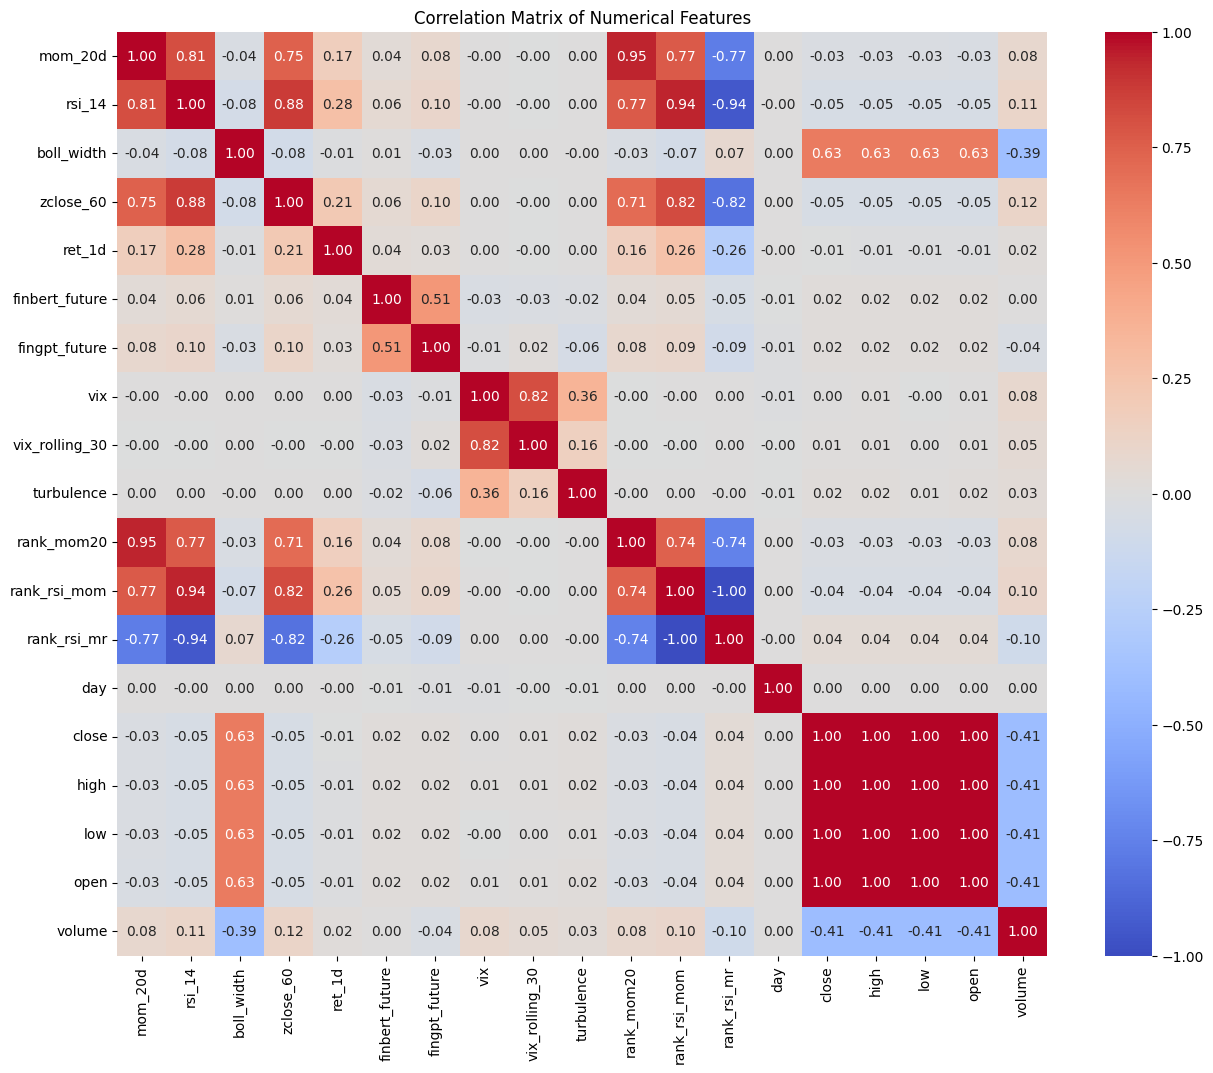

In [210]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is called df
# Select only numerical columns
numerical_cols = train_scaled.select_dtypes(include=['float64', 'int64']).columns
numerical_df = train_scaled[numerical_cols]

# Compute the correlation matrix
corr_matrix = numerical_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [211]:
train_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12852 entries, 0 to 12851
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   mom_20d         12852 non-null  float64       
 1   rsi_14          12852 non-null  float64       
 2   boll_width      12852 non-null  float64       
 3   zclose_60       12852 non-null  float64       
 4   ret_1d          12852 non-null  float64       
 5   finbert_future  12852 non-null  float64       
 6   fingpt_future   12852 non-null  float64       
 7   vix             12852 non-null  float64       
 8   vix_rolling_30  12852 non-null  float64       
 9   turbulence      12852 non-null  float64       
 10  rank_mom20      12852 non-null  float64       
 11  rank_rsi_mom    12852 non-null  float64       
 12  rank_rsi_mr     12852 non-null  float64       
 13  day             12852 non-null  float64       
 14  close           12852 non-null  float64       
 15  da

In [212]:
trade_scaled

,mom_20d,rsi_14,boll_width,zclose_60,ret_1d,finbert_future,fingpt_future,vix,vix_rolling_30,turbulence,...,rank_rsi_mom,rank_rsi_mr,day,close,date,tic,high,low,open,volume
0,-1.121865,-1.137090,0.348229,-1.393011,-1.425625,-1.299134,-2.126781,1.234195,1.266901,8.368588,...,0.25,0.75,1.0,123.330643,2023-01-03,AAPL,129.079559,122.443158,128.468186,112117500.0
1,1.148399,1.009871,-0.139716,0.882887,0.914768,-0.135715,1.174313,1.234195,1.266901,8.368588,...,1.00,0.00,1.0,195.389999,2023-01-03,BA,197.179993,192.399994,192.949997,8624600.0
2,-0.472748,-0.519097,1.086852,-0.018725,0.267751,2.112041,-1.216352,1.234195,1.266901,8.368588,...,0.50,0.50,1.0,324.413483,2023-01-03,GS,326.643584,321.218257,323.738830,1589700.0
3,0.446214,0.646316,-1.295365,0.528849,0.243105,-0.965418,-2.535467,1.234195,1.266901,8.368588,...,0.75,0.25,1.0,126.102333,2023-01-03,JPM,127.614227,124.954425,126.214334,11054800.0
4,-1.153315,-1.090377,0.326093,-1.340690,-0.358936,-2.507427,-3.172195,1.042584,1.256614,2.751408,...,0.25,0.75,2.0,124.602707,2023-01-04,AAPL,126.870724,123.340509,125.125335,89113600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2411,0.173177,0.255879,-0.554277,0.479158,-0.209301,0.192844,1.995529,0.433306,1.626682,3.642169,...,0.75,0.25,3.0,263.102478,2025-05-29,JPM,264.137500,261.271304,263.530409,5081200.0
2412,-1.417181,-1.344863,-0.589563,-1.489711,1.429485,-0.252350,-0.003628,0.301977,1.496282,0.200606,...,0.25,0.75,4.0,200.622314,2025-05-30,AAPL,201.731057,196.556921,199.143981,70819900.0
2413,0.913193,1.057963,-0.330726,0.644054,-0.879478,0.661807,-0.174005,0.301977,1.496282,0.200606,...,1.00,0.00,4.0,207.320007,2025-05-30,BA,207.699997,204.350006,206.770004,7485100.0
2414,0.375837,0.019149,1.489603,0.358070,-0.401141,0.830998,0.787771,0.301977,1.496282,0.200606,...,0.50,0.50,4.0,600.450012,2025-05-30,GS,603.599976,593.830017,600.000000,2129500.0


In [213]:
train_scaled

,mom_20d,rsi_14,boll_width,zclose_60,ret_1d,finbert_future,fingpt_future,vix,vix_rolling_30,turbulence,...,rank_rsi_mom,rank_rsi_mr,day,close,date,tic,high,low,open,volume
0,0.685504,0.699623,-0.921902,0.987331,1.428022,0.527989,0.085335,-0.210098,-0.233264,0.000000,...,0.75,0.25,1.0,7.080243,2010-03-30,AAPL,7.129177,7.032211,7.102758,527310000.0
1,1.021685,0.797585,0.216156,0.659698,-0.323628,-0.055880,1.321702,-0.210098,0.530735,0.000000,...,1.00,0.00,1.0,57.688480,2010-03-30,BA,58.198444,57.037297,57.931691,4381300.0
2,-0.733190,-1.362432,1.315768,-1.165293,-0.903033,0.374017,1.253673,-0.210098,0.530735,0.000000,...,0.25,0.75,1.0,130.988632,2010-03-30,GS,133.587305,130.468891,133.189857,8184600.0
3,-0.973999,-0.134776,-0.610023,-0.481736,-0.201360,0.805344,1.452810,-0.210098,0.530735,0.000000,...,0.50,0.50,1.0,29.849312,2010-03-30,JPM,30.164007,29.702006,30.063573,30296300.0
4,0.785931,0.815579,-1.001679,1.025395,0.084739,0.348693,-0.366311,-0.147612,-0.198353,0.000000,...,1.00,0.00,2.0,7.054726,2010-03-31,AAPL,7.103059,7.038515,7.069436,430659600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12847,0.215076,0.658768,-1.093502,0.528741,-0.460089,-1.626983,-2.301380,0.375373,0.486413,2.349754,...,0.75,0.25,3.0,124.329147,2022-12-29,JPM,124.375813,123.479876,124.058493,6585200.0
12848,-0.878034,-0.894195,0.194322,-1.357444,-0.479076,-1.360031,-1.246097,0.406616,0.474068,0.532288,...,0.25,0.75,4.0,128.123032,2022-12-30,AAPL,128.142758,125.657807,126.624181,77034200.0
12849,1.302316,1.008059,-0.297552,0.915669,1.043935,0.083169,0.100484,0.406616,0.474068,0.532288,...,1.00,0.00,4.0,190.490005,2022-12-30,BA,190.649994,187.039993,187.500000,4007400.0
12850,-0.682791,-0.824314,1.249190,-0.111763,-1.154535,0.695530,-1.885658,0.406616,0.474068,0.532288,...,0.50,0.50,4.0,321.752258,2022-12-30,GS,322.042731,318.022928,320.215540,1031400.0


In [214]:
import pandas as pd
import numpy as np

n_repeat = 4  # number of rows per index
n_rows = len(train_scaled)

# create the new index
new_index = np.arange(n_rows // n_repeat + 1).repeat(n_repeat)[:n_rows]

# assign it to the DataFrame
train_scaled.index = new_index

In [215]:
import pandas as pd
import numpy as np

n_repeat = 4  # number of rows per index
n_rows = len(trade_scaled)

# create the new index
new_index = np.arange(n_rows // n_repeat + 1).repeat(n_repeat)[:n_rows]

# assign it to the DataFrame
trade_scaled.index = new_index

In [216]:
trade_scaled

,mom_20d,rsi_14,boll_width,zclose_60,ret_1d,finbert_future,fingpt_future,vix,vix_rolling_30,turbulence,...,rank_rsi_mom,rank_rsi_mr,day,close,date,tic,high,low,open,volume
0,-1.121865,-1.137090,0.348229,-1.393011,-1.425625,-1.299134,-2.126781,1.234195,1.266901,8.368588,...,0.25,0.75,1.0,123.330643,2023-01-03,AAPL,129.079559,122.443158,128.468186,112117500.0
0,1.148399,1.009871,-0.139716,0.882887,0.914768,-0.135715,1.174313,1.234195,1.266901,8.368588,...,1.00,0.00,1.0,195.389999,2023-01-03,BA,197.179993,192.399994,192.949997,8624600.0
0,-0.472748,-0.519097,1.086852,-0.018725,0.267751,2.112041,-1.216352,1.234195,1.266901,8.368588,...,0.50,0.50,1.0,324.413483,2023-01-03,GS,326.643584,321.218257,323.738830,1589700.0
0,0.446214,0.646316,-1.295365,0.528849,0.243105,-0.965418,-2.535467,1.234195,1.266901,8.368588,...,0.75,0.25,1.0,126.102333,2023-01-03,JPM,127.614227,124.954425,126.214334,11054800.0
1,-1.153315,-1.090377,0.326093,-1.340690,-0.358936,-2.507427,-3.172195,1.042584,1.256614,2.751408,...,0.25,0.75,2.0,124.602707,2023-01-04,AAPL,126.870724,123.340509,125.125335,89113600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
602,0.173177,0.255879,-0.554277,0.479158,-0.209301,0.192844,1.995529,0.433306,1.626682,3.642169,...,0.75,0.25,3.0,263.102478,2025-05-29,JPM,264.137500,261.271304,263.530409,5081200.0
603,-1.417181,-1.344863,-0.589563,-1.489711,1.429485,-0.252350,-0.003628,0.301977,1.496282,0.200606,...,0.25,0.75,4.0,200.622314,2025-05-30,AAPL,201.731057,196.556921,199.143981,70819900.0
603,0.913193,1.057963,-0.330726,0.644054,-0.879478,0.661807,-0.174005,0.301977,1.496282,0.200606,...,1.00,0.00,4.0,207.320007,2025-05-30,BA,207.699997,204.350006,206.770004,7485100.0
603,0.375837,0.019149,1.489603,0.358070,-0.401141,0.830998,0.787771,0.301977,1.496282,0.200606,...,0.50,0.50,4.0,600.450012,2025-05-30,GS,603.599976,593.830017,600.000000,2129500.0


In [217]:
train_scaled

,mom_20d,rsi_14,boll_width,zclose_60,ret_1d,finbert_future,fingpt_future,vix,vix_rolling_30,turbulence,...,rank_rsi_mom,rank_rsi_mr,day,close,date,tic,high,low,open,volume
0,0.685504,0.699623,-0.921902,0.987331,1.428022,0.527989,0.085335,-0.210098,-0.233264,0.000000,...,0.75,0.25,1.0,7.080243,2010-03-30,AAPL,7.129177,7.032211,7.102758,527310000.0
0,1.021685,0.797585,0.216156,0.659698,-0.323628,-0.055880,1.321702,-0.210098,0.530735,0.000000,...,1.00,0.00,1.0,57.688480,2010-03-30,BA,58.198444,57.037297,57.931691,4381300.0
0,-0.733190,-1.362432,1.315768,-1.165293,-0.903033,0.374017,1.253673,-0.210098,0.530735,0.000000,...,0.25,0.75,1.0,130.988632,2010-03-30,GS,133.587305,130.468891,133.189857,8184600.0
0,-0.973999,-0.134776,-0.610023,-0.481736,-0.201360,0.805344,1.452810,-0.210098,0.530735,0.000000,...,0.50,0.50,1.0,29.849312,2010-03-30,JPM,30.164007,29.702006,30.063573,30296300.0
1,0.785931,0.815579,-1.001679,1.025395,0.084739,0.348693,-0.366311,-0.147612,-0.198353,0.000000,...,1.00,0.00,2.0,7.054726,2010-03-31,AAPL,7.103059,7.038515,7.069436,430659600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3211,0.215076,0.658768,-1.093502,0.528741,-0.460089,-1.626983,-2.301380,0.375373,0.486413,2.349754,...,0.75,0.25,3.0,124.329147,2022-12-29,JPM,124.375813,123.479876,124.058493,6585200.0
3212,-0.878034,-0.894195,0.194322,-1.357444,-0.479076,-1.360031,-1.246097,0.406616,0.474068,0.532288,...,0.25,0.75,4.0,128.123032,2022-12-30,AAPL,128.142758,125.657807,126.624181,77034200.0
3212,1.302316,1.008059,-0.297552,0.915669,1.043935,0.083169,0.100484,0.406616,0.474068,0.532288,...,1.00,0.00,4.0,190.490005,2022-12-30,BA,190.649994,187.039993,187.500000,4007400.0
3212,-0.682791,-0.824314,1.249190,-0.111763,-1.154535,0.695530,-1.885658,0.406616,0.474068,0.532288,...,0.50,0.50,4.0,321.752258,2022-12-30,GS,322.042731,318.022928,320.215540,1031400.0


In [218]:
def create_env(train, _ind, _hmax, _initial_amount, _reward_scaling):
    stock_dimension = len(train.tic.unique())
    state_space = 1 + stock_dimension + len(_ind) * stock_dimension
    print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

    buy_cost_list = sell_cost_list = [0.001] * stock_dimension
    num_stock_shares = [0] * stock_dimension

    env_kwargs = {
        "hmax": _hmax,
        "initial_amount": _initial_amount,
        "num_stock_shares": num_stock_shares,
        "buy_cost_pct": buy_cost_list,
        "sell_cost_pct": sell_cost_list,
        "state_space": state_space,
        "stock_dim": stock_dimension,
        "tech_indicator_list": _ind,
        "action_space": stock_dimension,
        "reward_scaling": _reward_scaling,
        "model_name": "ppo",
        "mode": "rl"
    }

    e_train_gym = StockTradingEnv(df = train, **env_kwargs)

    env_train, _ = e_train_gym.get_sb_env()
    return e_train_gym, env_train, env_kwargs

In [219]:
def run_wandb(env_kwargs, _name, algorithm, _total_timesteps, params, _reward, _notes=""):
    run = wandb.init(
        entity="influx_m",
        project="RL-DOW30-4SUB-analysis_reward",
        name=_name,
        group=algorithm,
        job_type="train",
        tags=["rl", algorithm, "stock-trading"],
        notes=_notes,
        sync_tensorboard=True,
        config={  # <-- fixed comma here
            # Environment parameters
            "hmax": env_kwargs["hmax"],
            "initial_amount": env_kwargs["initial_amount"],
            "num_stock_shares": env_kwargs["num_stock_shares"],
            "buy_cost_pct": env_kwargs["buy_cost_pct"],
            "sell_cost_pct": env_kwargs["sell_cost_pct"],
            "state_space": env_kwargs["state_space"],
            "stock_dim": env_kwargs["stock_dim"],
            "tech_indicator_list": env_kwargs["tech_indicator_list"],
            "action_space": env_kwargs["action_space"],
            "reward_scaling": env_kwargs["reward_scaling"],
            "total_timesteps": _total_timesteps,
            "params_model": params,
            "reward": _reward
        },
        dir="./wandb_logs",
        mode="online",
    )

    return run

In [220]:
def run_model(algorithm, _total_timesteps, it):
    wandb_callback = WandbCallback(
        model_save_path="./models/",
        verbose=2,
        model_save_freq=10000,
    )

    tmp_path = f'./{algorithm}-{it}'

    agent = DRLAgent(env=env_train)
    model = agent.get_model(algorithm, tensorboard_log=tmp_path)

    new_logger = configure(tmp_path, ["stdout", "csv", "tensorboard"])
    model.set_logger(new_logger)

    trained = agent.train_model(
        model=model,
        tb_log_name=algorithm,
        total_timesteps=_total_timesteps,
        callbacks=[wandb_callback]
    )

    return trained, model

In [221]:
def backtest(trained, train, trade, _ind, _hmax, _initial_amount, _reward_scaling):
    stock_dimension = len(trade.tic.unique())
    state_space = 1 + stock_dimension + len(_ind) * stock_dimension
    print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

    buy_cost_list = sell_cost_list = [0.001] * stock_dimension
    num_stock_shares = [0] * stock_dimension

    env_kwargs = {
        "hmax": _hmax,
        "initial_amount": _initial_amount,
        "num_stock_shares": num_stock_shares,
        "buy_cost_pct": buy_cost_list,
        "sell_cost_pct": sell_cost_list,
        "state_space": state_space,
        "stock_dim": stock_dimension,
        "tech_indicator_list": _ind,
        "action_space": stock_dimension,
        "reward_scaling": _reward_scaling,
        "model_name": "ppo",
        "mode": "rl"
    }

    e_trade_gym = StockTradingEnv(df = trade, **env_kwargs)

    df_account_value, df_actions = DRLAgent.DRL_prediction(
        model=trained,
        environment = e_trade_gym)

    return e_trade_gym, df_account_value, df_actions

In [222]:
def analysis_backtest(trade, train, df_account_value, df_actions):
    df_mvo, df_ew, df_bh, df_djia = build_benchmarks(trade, train)
    df_result, results = analysis_metrics_rl_benchmarks(df_account_value, df_mvo, df_ew, df_bh, df_djia)
    trade_metrics = analysis_trade_metrics(trade, df_actions)

    return df_result, results, trade_metrics

In [223]:
# Algorithms to run
ALGORITHMS = ["ppo"]

TOT_TIMESTEPS = {
    "a2c": 100_000,           # on-policy, needs many steps
    "ppo": 500_000,           # stable, multiple epochs over data
    "trpo": 300_000,          # similar to PPO but slower updates
    "rppo": 300_000, # needs sequence data, similar to PPO
    "td3": 150_000,           # off-policy, more sample efficient
    "sac": 150_000,           # off-policy, stable and efficient
    "crossq": 150_000,        # off-policy, similar to SAC/TD3
}

# Your fixed parameters (except algorithm-specific ones)
params = {
    "ind_train": INDICATORS_DOW_30,
    "hmax_train": 100,
    "initial_amount_train": 1_000_000,
    "reward_scaling_train": 10.0,   # scale = 1 because we normalized reward
    "hmax_test": 100,
    "initial_amount_test": 1_000_000,
    "reward_scaling_test": 10.0,
}

In [224]:
# Store all results here
all_results = {}

for i in range(38, 38 + 1):
    for algo in ALGORITHMS:
        print(f"\n=== Starting {algo.upper()} ===")

        # Step 1: Create environment kwargs for training
        e_train_gym, env_train, env_kwargs = create_env(
            train_scaled,
            params["ind_train"],
            params["hmax_train"],
            params["initial_amount_train"],
            params["reward_scaling_train"]
        )
        print("Step 1 done: Environment created")

        # Step 2: Initialize wandb run
        run = run_wandb(
            env_kwargs,
            f"init {algo} {i}",
            algo,
            TOT_TIMESTEPS[algo],
            DEFAULT_PARAMS[algo],
            _reward="simple return",
            _notes=f"Training {algo} - change list of indicators - normalize futures"
        )

        print("Step 2 done: wandb run initialized")


        # Step 3: Train the model
        trained_model, model = run_model(algo, TOT_TIMESTEPS[algo], i)
        print("Step 3 done: Model trained")

        """
        # Step 4: Backtest the trained model
        e_eval_gym, df_eval_value, df_eval_actions = backtest(
            trained_model,
            train,
            valid,
            params["ind_train"],
            params["hmax_test"],
            params["initial_amount_test"],
            params["reward_scaling_test"],
        )
        print("Step 4 done: Backtest valid completed")

        """

        # Step 4: Backtest the trained model
        e_trade_gym, df_trade_value, df_trade_actions = backtest(
            trained_model,
            train_scaled,
            trade_scaled,
            params["ind_train"],
            params["hmax_test"],
            params["initial_amount_test"],
            params["reward_scaling_test"],
        )
        print("Step 5 done: Backtest test completed")

        #df_res_valid, res_valid, valid_metrics = analysis_backtest(valid, train, df_eval_value, df_eval_actions)
        print("Step 6 done: Backtest valid analysis completed")

        df_res_trade, res_trade, trade_metrics = analysis_backtest(trade_scaled, train_scaled, df_trade_value, df_trade_actions)
        print("Step 7 done: Backtest test analysis completed")

        # Step 6: Log results to wandb
        run.log({"res_trade": res_trade['RL']})
        #run.log({"res_valid": res_valid['RL']})
        run.log({"trade_metrics": trade_metrics})
        #run.log({"valid_metrics": valid_metrics})
        print("Step 8 done: Results logged to wandb")

        # Step 7: Save results in dict for later use
        all_results[f"{i}-{algo}"] = {
            #"df_res_valid": df_res_valid.to_dict(orient="records"),
            #"res_valid": res_valid,
            #"valid_metrics": valid_metrics,
            "df_res_trade": df_res_trade.to_dict(orient="records"),
            "res_trade": res_trade,
            "trade_metrics": trade_metrics,
        }

        print(f"Step 8 done: Results saved for {algo.upper()}")


=== Starting PPO ===
Stock Dimension: 4, State Space: 45
Step 1 done: Environment created


actions/max,▅▇▇▇█▆▆▆▄▅▇▇▇▄▅▅▆▅▆▃▄▄▄▄▃▃▃▃▃▃▂▂▂▁▃▃▃▃▄▄
actions/mean,████████▇▇▇▆▅▅▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▁▂▁▂▁▂▁▁▁▁▁
actions/min,█▇▇▇▇▇▇▇▇▇▇▇▇▇▇▆▆▅▆▆▄▄▅▅▅▃▃▅▄▄▃▄▂▂▂▃▁▁▂▁
actions/std,▁▁▁▂▂▂▂▂▂▂▃▂▃▄▄▆▅▅▄▄▄▅▄▄▄▅▄▄▄▅▆▆▆▆▆▇█▇▇▇
global_step,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
time/fps,█▇▇▄▄▁▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▄▄▄▄▄
time/training_start,▁
train/approx_kl,▁▁▃▃▅▁▂▁█▂▄▄▅▄▆▆▄▇▂▂▂▅▃▂▃▃▃█▅▆▃▆▂▇▆▂▆▄▄▄
train/clip_fraction,▁▁▁▂▁▂▁▆▁▁▄▅▄▁▁▇█▁▂▂▂█▂▁▂▄▂▂▂▅▁▅▃▂▁▁▁▃▂█
train/clip_range,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/entropy_loss,█████▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁


Step 2 done: wandb run initialized
[DRLAgent] Initializing model ppo with kwargs: {'policy': 'MlpPolicy', 'n_steps': 512, 'batch_size': 128, 'gamma': 0.99, 'learning_rate': 0.0001, 'ent_coef': 0.05, 'clip_range': 0.3, 'n_epochs': 10, 'gae_lambda': 0.95, 'max_grad_norm': 0.5}
Using cpu device


/usr/local/lib/python3.10/site-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(
wandb: WARNING When using several event log directories, please call `wandb.tensorboard.patch(root_logdir="...")` before `wandb.init`


Logging to ./ppo-38
[DRLAgent] Starting training for 500000 timesteps...
[TB] Training started at 1755703557.202629
------------------------------------------
| actions/               |               |
|    max                 | 3.61          |
|    mean                | 0.018         |
|    min                 | -3.03         |
|    std                 | 1             |
| time/                  |               |
|    fps                 | 239           |
|    iterations          | 1             |
|    time_elapsed        | 2             |
|    total_timesteps     | 512           |
|    training_start      | 1.76e+09      |
| train/                 |               |
|    learning_rate       | 0.0001        |
|    rollout_reward_max  | 0.157         |
|    rollout_reward_mean | -0.00181      |
|    rollout_reward_min  | -0.287        |
|    step_reward         | -0.0137476865 |
------------------------------------------
------------------------------------------
| actions/              

/tmp/ipykernel_10/217127983.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  djia = yf.download('^DJI', start=TRADE_START_DATE, end=TRADE_END_DATE, progress=False)


Step 7 done: Backtest test analysis completed
Step 8 done: Results logged to wandb
Step 8 done: Results saved for PPO


In [ ]:
e_train_gym, env_train, env_kwargs = create_env(
    train_scaled,
    params["ind_train"],
    params["hmax_train"],
    params["initial_amount_train"],
    params["reward_scaling_train"]
)


In [ ]:
train_scaled

In [228]:
all_results["38-ppo"]

{'df_res_trade': [{'RL': Timestamp('2023-01-03 00:00:00'),
   'DIJA': Timestamp('2024-01-02 00:00:00'),
   'MVO': Timestamp('2023-01-03 00:00:00'),
   'EW': Timestamp('2023-01-03 00:00:00'),
   'BH': Timestamp('2023-01-03 00:00:00')},
  {'RL': Timestamp('2025-05-30 00:00:00'),
   'DIJA': Timestamp('2025-05-30 00:00:00'),
   'MVO': Timestamp('2025-05-30 00:00:00'),
   'EW': Timestamp('2025-05-30 00:00:00'),
   'BH': Timestamp('2025-05-30 00:00:00')},
  {'RL': 878, 'DIJA': 514, 'MVO': 878, 'EW': 878, 'BH': 878},
  {'RL': 51.162976705346665,
   'DIJA': 12.077493125359261,
   'MVO': 81.599461353673,
   'EW': 55.192634100828286,
   'BH': 65.55348426804512},
  {'RL': 18.754400044255682,
   'DIJA': 8.439607041696595,
   'MVO': 28.17172979004019,
   'EW': 20.061237180637036,
   'BH': 23.33287121858605},
  {'RL': 18.754400044255682,
   'DIJA': 8.439607041696595,
   'MVO': 28.17172979004019,
   'EW': 20.061237180637036,
   'BH': 23.33287121858605},
  {'RL': 19.284948155478705,
   'DIJA': 15.5202

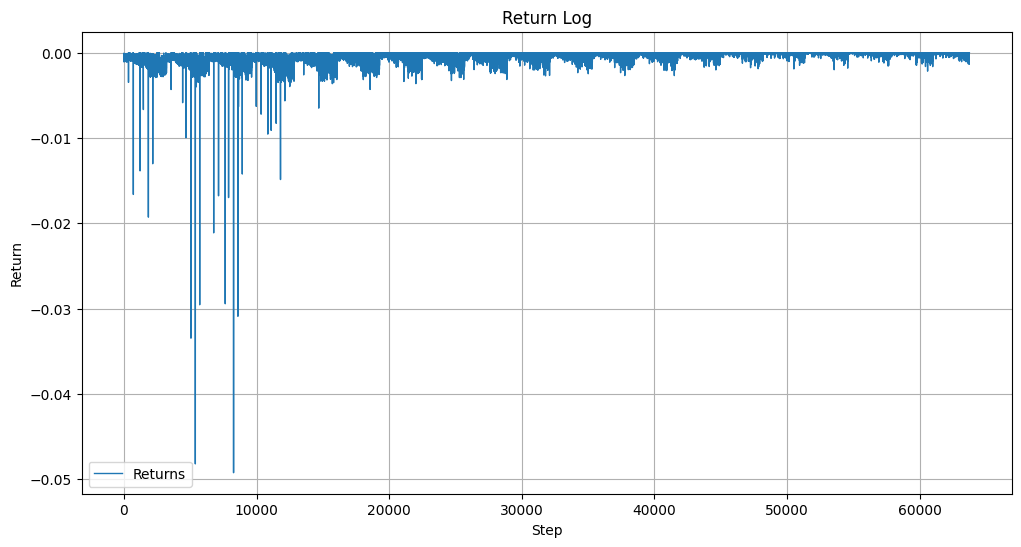

In [156]:
import matplotlib.pyplot as plt

# Plot return_log
plt.figure(figsize=(12,6))
plt.plot([u[1] for u in e_train_gym.vol_log], label="Returns", linewidth=1)

plt.title("Return Log")
plt.xlabel("Step")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

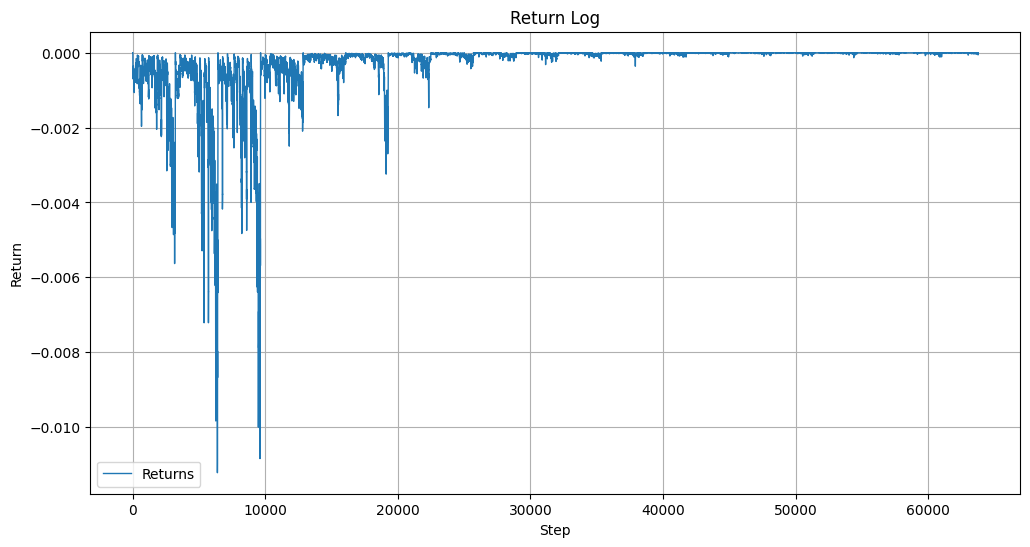

In [157]:
import matplotlib.pyplot as plt

# Plot return_log
plt.figure(figsize=(12,6))
plt.plot([u[0] for u in e_train_gym.vol_log], label="Returns", linewidth=1)

plt.title("Return Log")
plt.xlabel("Step")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

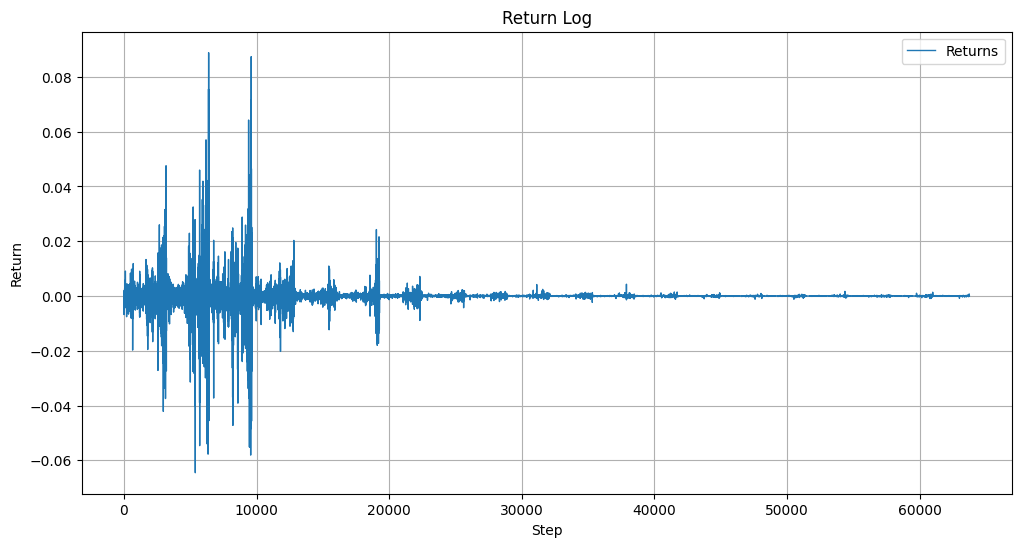

In [158]:
import matplotlib.pyplot as plt

# Plot return_log
plt.figure(figsize=(12,6))
plt.plot(e_train_gym.return_log, label="Returns", linewidth=1)

plt.title("Return Log")
plt.xlabel("Step")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()